## Imports

In [9]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
# ── Parameters — edit these to select what to plot ───────────────────────────
RESULTS_DIR = Path('/data/equake_results/lagged_kin_dec_20_pcs/')
SESSION     = 'M061_2025_03_06_14_00'
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'

# Visualisation windows
BASELINE_S  = (-1.0, -0.3)
SPAGHETTI_S = (-0.1,  0.3)

# List available files
files = sorted(RESULTS_DIR.glob('lagged_dec_*.pkl'))
print(f'Found {len(files)} result files:')
for f in files:
    print(f'  {f.name}')


Found 9 result files:
  lagged_dec_MOp_M061_2025_03_04_10_00.pkl
  lagged_dec_MOp_M061_2025_03_05_14_00.pkl
  lagged_dec_MOp_M061_2025_03_06_14_00.pkl
  lagged_dec_MOp_M062_2025_03_20_14_00.pkl
  lagged_dec_MOp_M062_2025_03_21_14_00.pkl
  lagged_dec_MOp_M063_2025_03_13_14_00.pkl
  lagged_dec_MOp_M063_2025_03_14_15_30.pkl
  lagged_dec_MOp_M078_2025_08_06_15_00.pkl
  lagged_dec_MOp_M086_2025_12_10_15_00.pkl


In [12]:
# ── Load results ──────────────────────────────────────────────────────────────
pkl_path = RESULTS_DIR / f'lagged_dec_{AREA}_{SESSION}.pkl'
with open(pkl_path, 'rb') as f:
    _raw = pickle.load(f)

# ── Read metadata (saved by script) or fall back to inferring from data ───────
if '_meta' in _raw:
    _meta        = _raw.pop('_meta')
    BIN_SIZE     = _meta['bin_size']
    WINDOW_S     = _meta['window_s']
    lags_ms      = _meta['lags_s'] * 1000        # stored in seconds → convert to ms
    time_step_s  = _meta['time_step_s']
    results_session = _raw
    print(f'Metadata loaded from pkl:')
    print(f'  bin_size={BIN_SIZE*1000:.0f} ms  window={WINDOW_S*1000:.0f} ms  '
          f'step={time_step_s*1000:.0f} ms  '
          f'lags={lags_ms[0]:.0f}→{lags_ms[-1]:.0f} ms  ({len(lags_ms)} lags)')
else:
    # Legacy pkl — infer what we can from the data shape
    results_session = _raw
    BIN_SIZE    = 0.01
    WINDOW_S    = 0.20
    n_lags      = next(iter(next(iter(results_session.values())).values())).shape[0]
    lags_ms     = np.arange(n_lags) * BIN_SIZE * 1000   # assume lags start at 0
    time_step_s = None
    print('WARNING: no _meta key found — re-run the script to save metadata.')

results  = results_session[KEYPOINT]
all_t    = np.array(sorted(results.keys()))
t_0_idx  = np.argmin(np.abs(lags_ms))

print(f'Loaded   : {pkl_path.name}')
print(f'Keypoints: {list(results_session.keys())}')
print(f'Time bins: {all_t[0]:.2f} → {all_t[-1]:.2f} s  ({len(all_t)} bins)')

Metadata loaded from pkl:
  bin_size=10 ms  window=200 ms  step=30 ms  lags=-250→250 ms  (51 lags)
Loaded   : lagged_dec_MOp_M061_2025_03_06_14_00.pkl
Keypoints: ['left_elbow']
Time bins: -0.80 → 1.27 s  (70 bins)


Deviation lags             : ±250 ms  (25 past, 25 future bins)
Baseline mean R² at lag 0  : 0.1611
Peak R² (max over time)    : 0.3816
Peak future dev            : 1.8296  at t=0.34 s
Peak past dev              : 2.1221  at t=0.37 s
Peak dev diff (fut-past)   : 0.8444  at t=0.73 s


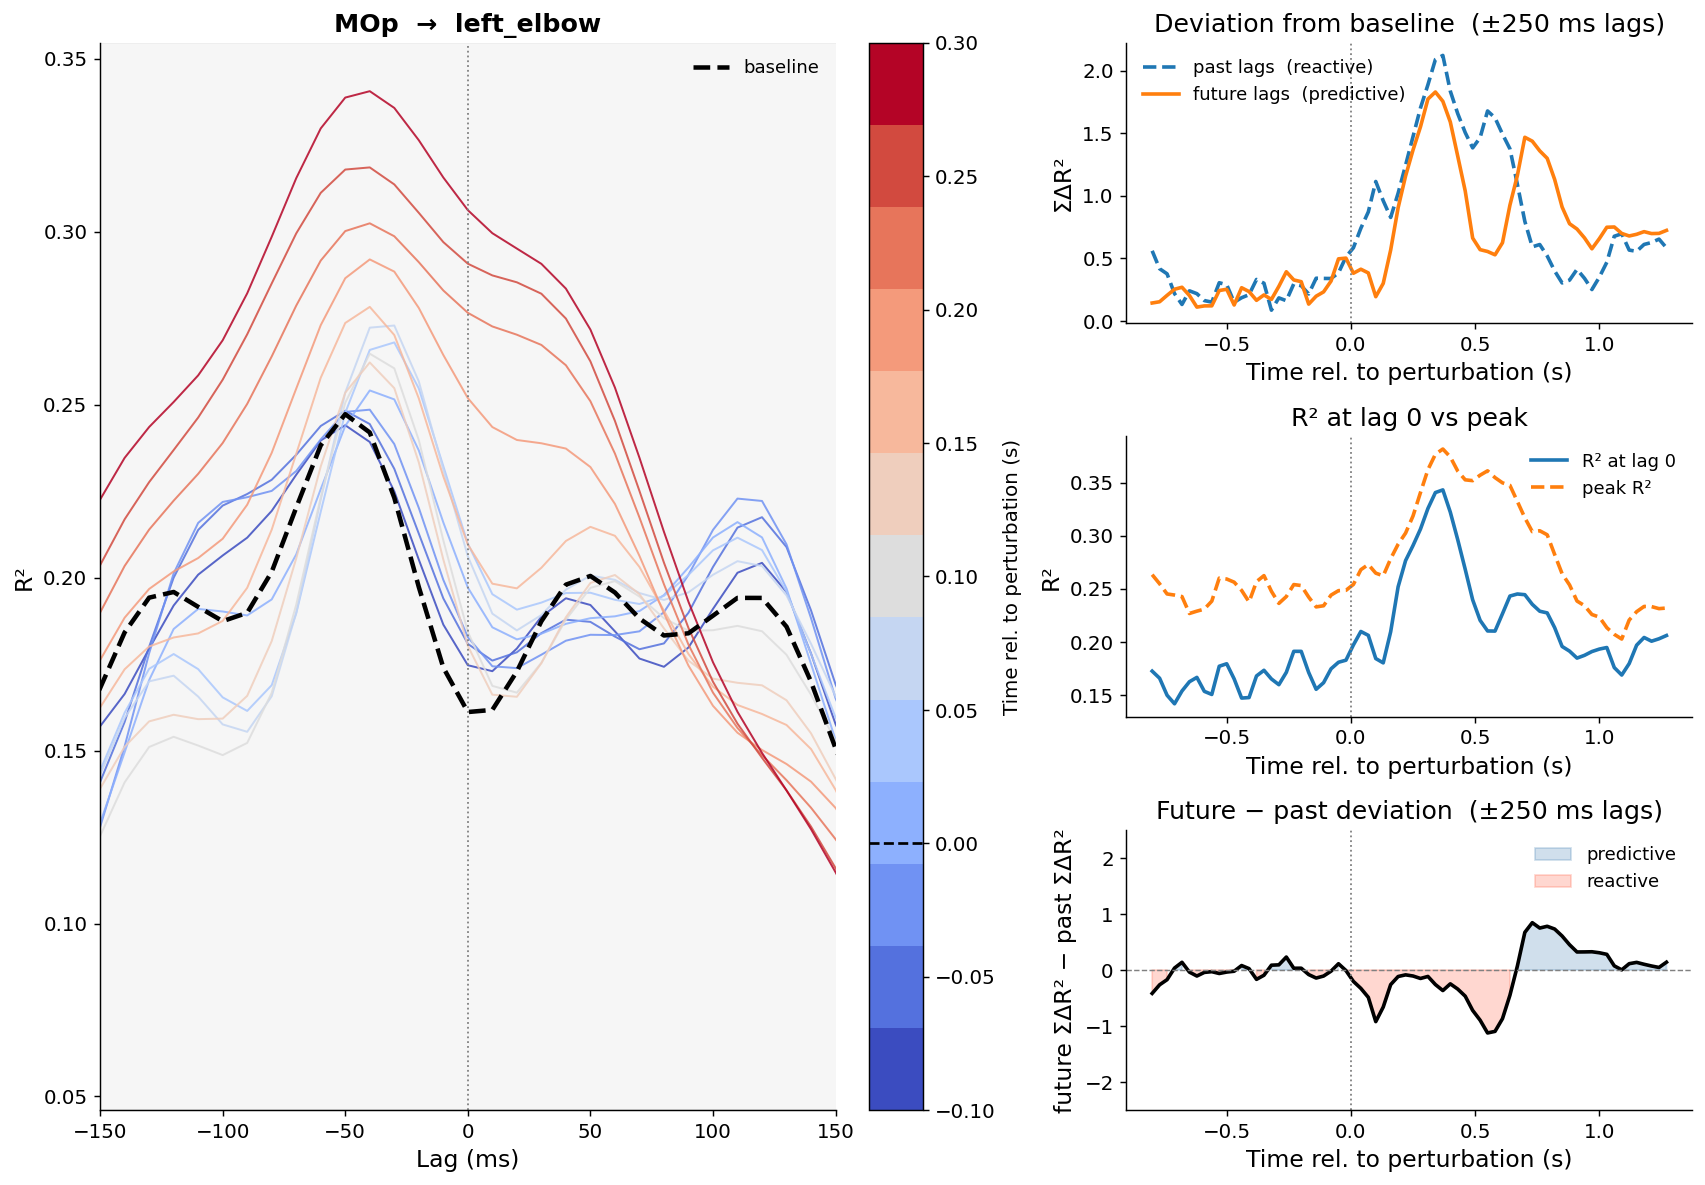

In [13]:
# ── Derived quantities ────────────────────────────────────────────────────────
bl_mask       = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
baseline_mean = np.array([results[t].mean(-1) for t in all_t[bl_mask]]).mean(0)

sp_mask = (all_t >= SPAGHETTI_S[0]) & (all_t <= SPAGHETTI_S[1])
sp_t    = all_t[sp_mask]

# Restrict deviation to ±100 ms lags
DEV_LAG_LIM_MS = 250
past_lag_mask   = (lags_ms >= -DEV_LAG_LIM_MS) & (lags_ms < 0)
future_lag_mask = (lags_ms > 0) & (lags_ms <= DEV_LAG_LIM_MS)

def _deviation(curve, baseline, mask):
    return np.sum(np.abs(curve[mask] - baseline[mask]))

past_dev   = np.array([_deviation(results[t].mean(-1), baseline_mean, past_lag_mask)   for t in all_t])
future_dev = np.array([_deviation(results[t].mean(-1), baseline_mean, future_lag_mask) for t in all_t])
dev_diff   = future_dev - past_dev

r2_at_lag0 = np.array([results[t].mean(-1)[t_0_idx]  for t in all_t])
peak_r2    = np.array([results[t].mean(-1).max()      for t in all_t])

print(f'Deviation lags             : ±{DEV_LAG_LIM_MS} ms  '
      f'({past_lag_mask.sum()} past, {future_lag_mask.sum()} future bins)')
print(f'Baseline mean R² at lag 0  : {baseline_mean[t_0_idx]:.4f}')
print(f'Peak R² (max over time)    : {peak_r2.max():.4f}')
print(f'Peak future dev            : {future_dev.max():.4f}  at t={all_t[future_dev.argmax()]:.2f} s')
print(f'Peak past dev              : {past_dev.max():.4f}  at t={all_t[past_dev.argmax()]:.2f} s')
print(f'Peak dev diff (fut-past)   : {dev_diff.max():.4f}  at t={all_t[dev_diff.argmax()]:.2f} s')

# ── Figure ────────────────────────────────────────────────────────────────────
PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_cmap = mpl.colormaps['coolwarm'].resampled(len(sp_t))
_norm = mpl.colors.Normalize(vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1])
_sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

with mpl.rc_context(PRES_RC):
    fig = plt.figure(figsize=(13, 9), constrained_layout=True)
    gs  = mpl.gridspec.GridSpec(nrows=3, ncols=2, figure=fig,
                                width_ratios=[1.3, 1], height_ratios=[1, 1, 1])

    ax_sp  = fig.add_subplot(gs[:, 0])    # spaghetti — spans all rows
    ax_dev = fig.add_subplot(gs[0, 1])    # deviation from baseline
    ax_pk  = fig.add_subplot(gs[1, 1])    # R² at lag 0 vs peak
    ax_dif = fig.add_subplot(gs[2, 1])    # future − past deviation

    # ── Spaghetti ─────────────────────────────────────────────────────────
    for t_s in sp_t:
        ax_sp.plot(lags_ms, results[t_s].mean(-1), color=_cmap(_norm(t_s)), lw=1.1, alpha=0.85)
    ax_sp.plot(lags_ms, baseline_mean, color='k', lw=2.5, ls='--', zorder=10, label='baseline')
    ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
    ax_sp.axvspan(-DEV_LAG_LIM_MS, DEV_LAG_LIM_MS, color='gray', alpha=0.07, zorder=0)
    ax_sp.set_xlabel('Lag (ms)')
    ax_sp.set_ylabel('R²')
    ax_sp.set_xlim(lags_ms[0], lags_ms[-1])
    ax_sp.set_xlim(-150, 150)

    ax_sp.set_title(f'{AREA}  →  {KEYPOINT}', fontweight='bold')
    ax_sp.legend(frameon=False, fontsize=10)
    cb = fig.colorbar(_sm, ax=ax_sp, pad=0.02)
    cb.set_label('Time rel. to perturbation (s)', fontsize=11)
    cb.ax.axhline(0, color='k', lw=1.5, ls='--')

    # ── Deviation from baseline ───────────────────────────────────────────
    ax_dev.plot(all_t, past_dev,   ls='--', lw=2, label='past lags  (reactive)')
    ax_dev.plot(all_t, future_dev, ls='-',  lw=2, label='future lags  (predictive)')
    ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
    ax_dev.set_xlabel('Time rel. to perturbation (s)')
    ax_dev.set_ylabel('ΣΔR²')
    ax_dev.set_title(f'Deviation from baseline  (±{DEV_LAG_LIM_MS} ms lags)')
    ax_dev.legend(frameon=False, fontsize=10)

    # ── R² at lag 0 vs peak R² ────────────────────────────────────────────
    ax_pk.plot(all_t, r2_at_lag0, lw=2, label='R² at lag 0')
    ax_pk.plot(all_t, peak_r2,    lw=2, label='peak R²', ls='--')
    ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
    ax_pk.set_xlabel('Time rel. to perturbation (s)')
    ax_pk.set_ylabel('R²')
    ax_pk.set_title('R² at lag 0 vs peak')
    ax_pk.legend(frameon=False, fontsize=10)

    # ── Future − past deviation ───────────────────────────────────────────
    ax_dif.plot(all_t, dev_diff, color='k', lw=2)
    ax_dif.fill_between(all_t, dev_diff, 0,
                        where=(dev_diff > 0), color='steelblue', alpha=0.25, label='predictive')
    ax_dif.fill_between(all_t, dev_diff, 0,
                        where=(dev_diff < 0), color='tomato', alpha=0.25, label='reactive')
    ax_dif.axhline(0, color='gray', lw=0.8, ls='--')
    ax_dif.axvline(0, color='gray', lw=1.0, ls=':')
    ax_dif.set_xlabel('Time rel. to perturbation (s)')
    ax_dif.set_ylabel('future ΣΔR² − past ΣΔR²')
    ax_dif.set_title(f'Future − past deviation  (±{DEV_LAG_LIM_MS} ms lags)')
    ax_dif.legend(frameon=False, fontsize=10)
    ax_dif.set_ylim(-2.5, 2.5)

    plt.show()

Baseline drift             : 0.0 ms
Drift at t=0               : 2.1 ms
Max drift (most predictive): 3.1 ms  at t=0.10 s
Min drift (most reactive)  : -2.9 ms  at t=0.34 s


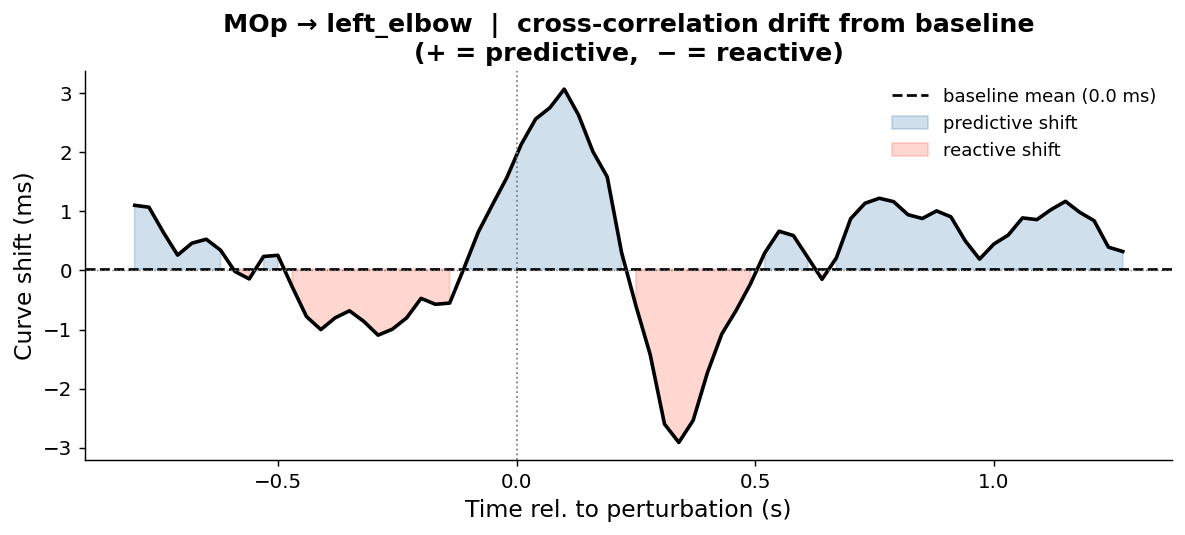

In [14]:
# ── Cross-correlation shift relative to baseline ──────────────────────────────
# For each time window, find the lag offset that best aligns the R²-vs-lag
# curve to the baseline curve via cross-correlation.
# Positive shift → curve moved right (predictive)
# Negative shift → curve moved left  (reactive)
#
# Both curves are normalised to [0,1] before xcorr so amplitude changes
# don't drive the result.

from scipy.signal import correlate

lag_step_ms = lags_ms[1] - lags_ms[0]   # spacing between lag bins (ms)
lag_offsets = np.arange(-(len(lags_ms) - 1), len(lags_ms)) * lag_step_ms

def _xcorr_shift(curve, baseline):
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    # sub-step refinement: fit parabola around peak
    pk = xc.argmax()
    if 0 < pk < len(xc) - 1:
        # parabolic interpolation
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * lag_step_ms - (len(lags_ms) - 1) * lag_step_ms
    return lag_offsets[pk]

drift = np.array([_xcorr_shift(results[t].mean(-1), baseline_mean) for t in all_t])
bl_drift = drift[bl_mask].mean()

print(f'Baseline drift             : {bl_drift:.1f} ms')
print(f'Drift at t=0               : {drift[np.argmin(np.abs(all_t))]:.1f} ms')
print(f'Max drift (most predictive): {drift.max():.1f} ms  at t={all_t[drift.argmax()]:.2f} s')
print(f'Min drift (most reactive)  : {drift.min():.1f} ms  at t={all_t[drift.argmin()]:.2f} s')

with mpl.rc_context(PRES_RC):
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    ax.plot(all_t, drift, color='k', lw=2)
    ax.axhline(bl_drift, color='k', lw=1.5, ls='--', label=f'baseline mean ({bl_drift:.1f} ms)')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.fill_between(all_t, drift, bl_drift,
                    where=(drift > bl_drift), color='steelblue', alpha=0.25, label='predictive shift')
    ax.fill_between(all_t, drift, bl_drift,
                    where=(drift < bl_drift), color='tomato',    alpha=0.25, label='reactive shift')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Curve shift (ms)')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  cross-correlation drift from baseline\n'
                 f'(+ = predictive,  − = reactive)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=10)
    plt.show()

## Load all sessions

In [65]:
RESULTS_DIR

PosixPath('/data/equake_results/lagged_kin_dec_20_pcs')

In [15]:
# ── Multi-session: load all sessions and compute metrics ──────────────────────
ALL_SESSIONS = [
    # 'M061_2025_03_04_10_00',
    # "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

_COM_LIM = 100   # ms

def _compute_com(curve, baseline, lags):
    mask = np.abs(lags) <= _COM_LIM
    dev  = np.abs(curve[mask] - baseline[mask])
    if dev.sum() == 0:
        return 0.0
    return np.sum(lags[mask] * dev) / dev.sum()

def _compute_drift(curve, baseline, lags):
    from scipy.signal import correlate
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    step = lags[1] - lags[0]
    pk   = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * step - (len(lags) - 1) * step
    return (pk - (len(lags) - 1)) * step

session_metrics = {}

for sess in ALL_SESSIONS:
    pkl_path = RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl'
    if not pkl_path.exists():
        print(f'  missing: {pkl_path.name}')
        continue

    with open(pkl_path, 'rb') as f:
        _r = pickle.load(f)

    _lags = _r.pop('_meta')['lags_s'] * 1000 if '_meta' in _r else lags_ms

    if KEYPOINT not in _r:
        print(f'  {sess}: keypoint {KEYPOINT} not found')
        continue

    _res   = _r[KEYPOINT]
    _all_t = np.array(sorted(_res.keys()))

    _bl_mask = (_all_t >= BASELINE_S[0]) & (_all_t < BASELINE_S[1])
    _bl_mean = np.array([_res[t].mean(-1) for t in _all_t[_bl_mask]]).mean(0)

    _com_arr   = np.array([_compute_com  (_res[t].mean(-1), _bl_mean, _lags) for t in _all_t])
    _drift_arr = np.array([_compute_drift(_res[t].mean(-1), _bl_mean, _lags) for t in _all_t])

    session_metrics[sess] = {
        't':      _all_t,
        'com':    _com_arr   - _com_arr[_bl_mask].mean(),
        'drift':  _drift_arr - _drift_arr[_bl_mask].mean(),
        'animal': sess[:4],
    }
    print(f'  loaded {sess[:4]} | {sess}')

print(f'\nLoaded {len(session_metrics)}/{len(ALL_SESSIONS)} sessions')

# ── Average within animal ──────────────────────────────────────────────────────
animals  = sorted(set(v['animal'] for v in session_metrics.values()))
common_t = next(iter(session_metrics.values()))['t']

animal_metrics = {}
for animal in animals:
    sess_list = [v for v in session_metrics.values() if v['animal'] == animal]
    animal_metrics[animal] = {
        'com':   np.mean([s['com']   for s in sess_list], axis=0),
        'drift': np.mean([s['drift'] for s in sess_list], axis=0),
        'n':     len(sess_list),
    }

print(f'Animals : {animals}')
print(f'Sessions: {[animal_metrics[a]["n"] for a in animals]} each')

  loaded M061 | M061_2025_03_06_14_00
  loaded M062 | M062_2025_03_20_14_00
  loaded M062 | M062_2025_03_21_14_00
  loaded M078 | M078_2025_08_06_15_00
  loaded M086 | M086_2025_12_10_15_00

Loaded 5/5 sessions
Animals : ['M061', 'M062', 'M078', 'M086']
Sessions: [1, 2, 1, 1] each


In [7]:
# ── Spaghetti multiplot — one figure per loaded session ───────────────────────
# Requires: f4at5w3b1xh (session_metrics) and cell-params (RESULTS_DIR, AREA,
#           KEYPOINT, BASELINE_S, SPAGHETTI_S)

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_DEV_LAG_LIM_MS = 250
BASELINE_S  = (-1, -0.5)

for sess in session_metrics:
    # ── reload raw results ─────────────────────────────────────────────────
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))
    _t0   = int(np.argmin(np.abs(_lags)))

    _bl_mask = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _bl_mean = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)

    _sp_mask = (_t >= SPAGHETTI_S[0]) & (_t <= SPAGHETTI_S[1])
    _sp_t    = _t[_sp_mask]

    _past_mask   = (_lags >= -_DEV_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _DEV_LAG_LIM_MS)

    _past_dev   = np.array([np.sum(np.abs(_res[ti].mean(-1)[_past_mask]   - _bl_mean[_past_mask]))   for ti in _t])
    print(_past_dev)
    _future_dev = np.array([np.sum(np.abs(_res[ti].mean(-1)[_future_mask] - _bl_mean[_future_mask])) for ti in _t])
    _dev_diff   = _future_dev - _past_dev
    _r2_lag0    = np.array([_res[ti].mean(-1)[_t0]   for ti in _t])
    _peak_r2    = np.array([_res[ti].mean(-1).max()  for ti in _t])

    _cmap = mpl.colormaps['coolwarm'].resampled(len(_sp_t))
    _norm = mpl.colors.Normalize(vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1])
    _sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

    print(f'\n{sess}  peak R²={_peak_r2.max():.3f}  '
          f'peak dev diff={_dev_diff.max():.3f} at t={_t[_dev_diff.argmax()]:.2f} s')

    with mpl.rc_context(_PRES_RC):
        fig = plt.figure(figsize=(13, 7), constrained_layout=True)
        gs  = mpl.gridspec.GridSpec(3, 2, figure=fig,
                                    width_ratios=[1.3, 1], height_ratios=[1, 1, 1])
        ax_sp  = fig.add_subplot(gs[:, 0])
        ax_dev = fig.add_subplot(gs[0, 1])
        ax_pk  = fig.add_subplot(gs[1, 1])
        ax_dif = fig.add_subplot(gs[2, 1])

        for ti in _sp_t:
            ax_sp.plot(_lags, _res[ti].mean(-1), color=_cmap(_norm(ti)), lw=1.1, alpha=0.85)
        ax_sp.plot(_lags, _bl_mean, color='k', lw=2.5, ls='--', zorder=10, label='baseline')
        ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
        ax_sp.axvspan(-_DEV_LAG_LIM_MS, _DEV_LAG_LIM_MS, color='gray', alpha=0.07, zorder=0)
        ax_sp.set_xlabel('Lag (ms)')
        ax_sp.set_ylabel('R²')
        ax_sp.set_xlim(_lags[0], _lags[-1])
        ax_sp.set_title(f'{AREA} → {KEYPOINT}  |  {sess}', fontweight='bold')
        ax_sp.legend(frameon=False, fontsize=10)
        cb = fig.colorbar(_sm, ax=ax_sp, pad=0.02)
        cb.set_label('Time rel. to perturbation (s)', fontsize=11)
        cb.ax.axhline(0, color='k', lw=1.5, ls='--')

        ax_dev.plot(_t, _past_dev,   ls='--', lw=2, label='past (reactive)')
        ax_dev.plot(_t, _future_dev, ls='-',  lw=2, label='future (predictive)')
        ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
        ax_dev.set_ylabel('ΣΔR²')
        ax_dev.set_title(f'Deviation from baseline  (±{_DEV_LAG_LIM_MS} ms)')
        ax_dev.legend(frameon=False, fontsize=10)

        ax_pk.plot(_t, _r2_lag0, lw=2, label='R² at lag 0')
        ax_pk.plot(_t, _peak_r2, lw=2, ls='--', label='peak R²')
        ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
        ax_pk.set_ylabel('R²')
        ax_pk.set_title('R² at lag 0 vs peak')
        ax_pk.legend(frameon=False, fontsize=10)

        ax_dif.plot(_t, _dev_diff, color='k', lw=2)
        ax_dif.fill_between(_t, _dev_diff, 0,
                            where=(_dev_diff > 0), color='steelblue', alpha=0.25, label='predictive')
        ax_dif.fill_between(_t, _dev_diff, 0,
                            where=(_dev_diff < 0), color='tomato',    alpha=0.25, label='reactive')
        ax_dif.axhline(0, color='gray', lw=0.8, ls='--')
        ax_dif.axvline(0, color='gray', lw=1.0, ls=':')
        ax_dif.set_xlabel('Time rel. to perturbation (s)')
        ax_dif.set_ylabel('future ΣΔR² − past ΣΔR²')
        ax_dif.set_title(f'Future − past deviation')
        ax_dif.legend(frameon=False, fontsize=10)
        ax_dif.set_ylim(-2.5, 2.5)

        plt.show()

NameError: name 'session_metrics' is not defined

Peak future−past deviation : -0.8252  at t=0.10 s  (±0.4872 SEM)


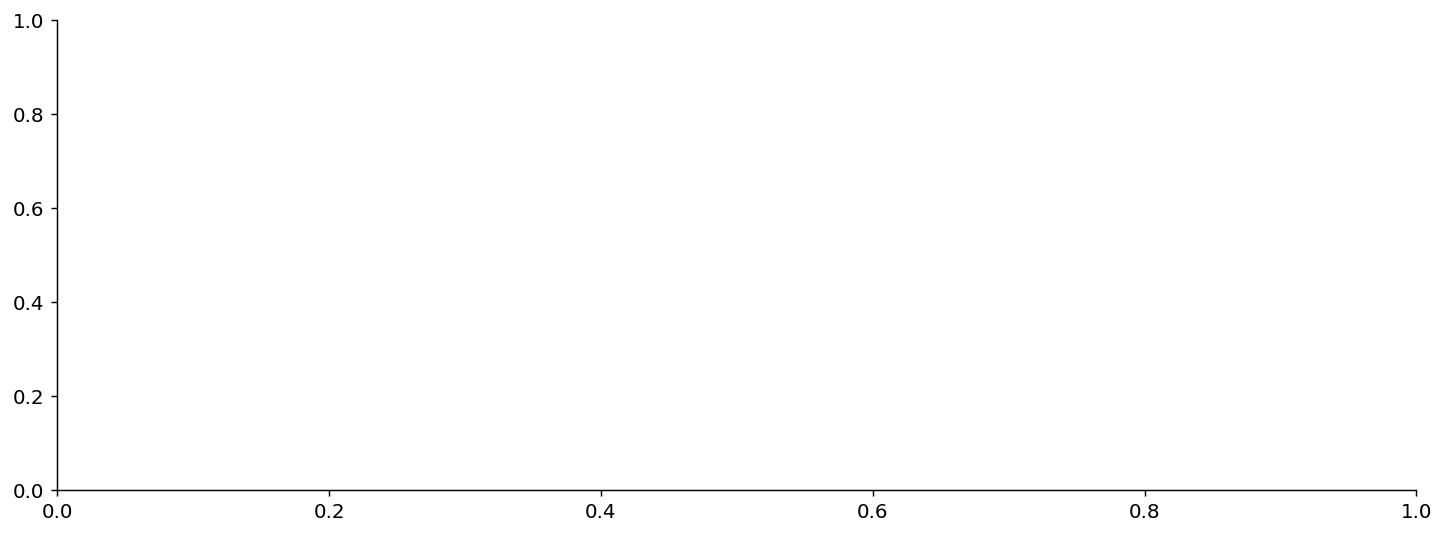

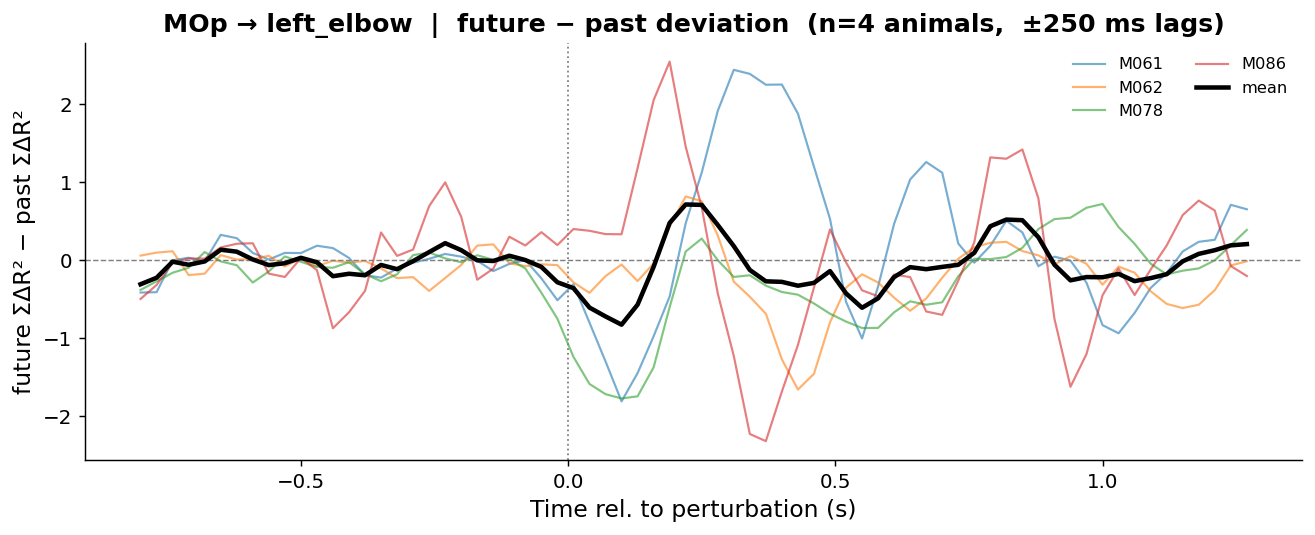

In [11]:
# ── Future − past deviation: all animals, one figure ─────────────────────────
# Requires: f4at5w3b1xh (session_metrics, animals) and cell-params

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_DEV_LAG_LIM_MS = 250
_cmap_a        = mpl.colormaps['tab10']
_animal_colors = {a: _cmap_a(i) for i, a in enumerate(animals)}

# ── compute dev_diff per session ───────────────────────────────────────────────
sess_dev_diff = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _bl_mask     = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _bl_mean     = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
    _past_mask   = (_lags >= -_DEV_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _DEV_LAG_LIM_MS)

    _past_dev   = np.array([np.sum(np.abs(_res[ti].mean(-1)[_past_mask]   - _bl_mean[_past_mask]))   for ti in _t])
    _future_dev = np.array([np.sum(np.abs(_res[ti].mean(-1)[_future_mask] - _bl_mean[_future_mask])) for ti in _t])
    _dev_diff   = _future_dev - _past_dev

    sess_dev_diff[sess] = {'t': _t, 'dev_diff': _dev_diff, 'animal': sess[:4]}

# ── average within animal ──────────────────────────────────────────────────────
_common_t = next(iter(sess_dev_diff.values()))['t']
animal_dev_diff = {}
for animal in animals:
    _traces = [v['dev_diff'] for v in sess_dev_diff.values() if v['animal'] == animal]
    animal_dev_diff[animal] = np.mean(_traces, axis=0)

stack      = np.array(list(animal_dev_diff.values()))
grand_mean = stack.mean(axis=0)
grand_sem  = stack.std(axis=0) / np.sqrt(len(animals))

peak_t = _common_t[np.abs(grand_mean).argmax()]
print(f'Peak future−past deviation : {grand_mean[np.abs(grand_mean).argmax()]:.4f}  '
      f'at t={peak_t:.2f} s  (±{grand_sem[np.abs(grand_mean).argmax()]:.4f} SEM)')

# ── plot ───────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    for animal in animals:
        ax.plot(_common_t, animal_dev_diff[animal],
                color=_animal_colors[animal], lw=1.2, alpha=0.6, label=animal)

    ax.plot(_common_t, grand_mean, color='k', lw=2.5, zorder=5, label='mean')
    # ax.fill_between(_common_t,
    #                 grand_mean - grand_sem,
    #                 grand_mean + grand_sem,
    #                 color='k', alpha=0.15, zorder=4)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean > 0), color='steelblue', alpha=0.15)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean < 0), color='tomato', alpha=0.15)

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('future ΣΔR² − past ΣΔR²')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  future − past deviation  '
                 f'(n={len(animals)} animals,  ±{_DEV_LAG_LIM_MS} ms lags)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.show()

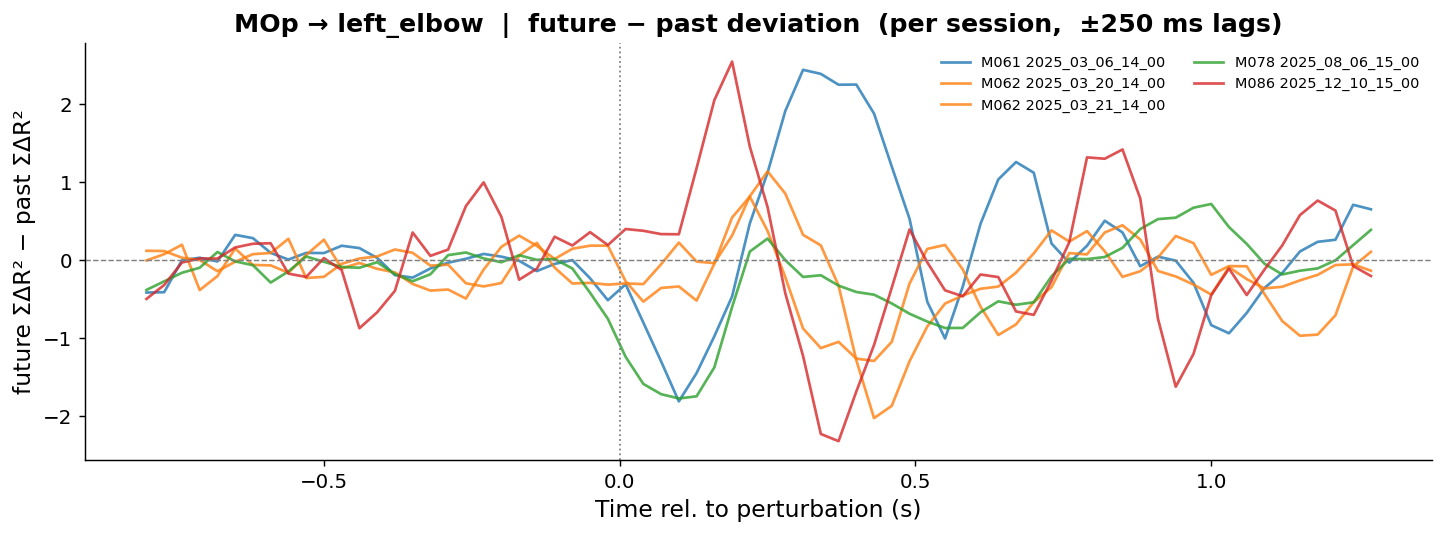

Session                              peak dev_diff  at t (s)
--------------------------------------------------------------
M061_2025_03_06_14_00                       2.4406      0.31
M062_2025_03_20_14_00                      -2.0230      0.43
M062_2025_03_21_14_00                      -1.2905      0.43
M078_2025_08_06_15_00                      -1.7709      0.10
M086_2025_12_10_15_00                       2.5455      0.19


In [12]:
# ── Future − past deviation: per-session traces, one figure ──────────────────
# Reuses sess_dev_diff computed in the cell above.
# Each session plotted individually, coloured by animal.

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_cmap_a        = mpl.colormaps['tab10']
_animal_colors = {a: _cmap_a(i) for i, a in enumerate(animals)}

with mpl.rc_context(_PRES_RC):
    fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)

    for sess, sd in sess_dev_diff.items():
        animal = sd['animal']
        label  = sess[5:]   # date part only
        ax.plot(sd['t'], sd['dev_diff'],
                color=_animal_colors[animal], lw=1.5, alpha=0.8, label=f'{animal} {label}')

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('future ΣΔR² − past ΣΔR²')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  future − past deviation  '
                 f'(per session,  ±{_DEV_LAG_LIM_MS} ms lags)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.show()

# also print peak per session for quick comparison
print(f"{'Session':<35} {'peak dev_diff':>14}  {'at t (s)':>8}")
print('-' * 62)
for sess, sd in sess_dev_diff.items():
    pk_idx = np.abs(sd['dev_diff']).argmax()
    print(f"{sess:<35} {sd['dev_diff'][pk_idx]:>14.4f}  {sd['t'][pk_idx]:>8.2f}")

M061_2025_03_06_14_00: peak future AUC=37.058  peak past AUC=45.160  peak diff=3.075 at t=0.76 s
M062_2025_03_20_14_00: peak future AUC=35.724  peak past AUC=57.952  peak diff=1.191 at t=0.10 s
M062_2025_03_21_14_00: peak future AUC=28.588  peak past AUC=44.011  peak diff=2.093 at t=-0.77 s
M078_2025_08_06_15_00: peak future AUC=38.697  peak past AUC=39.052  peak diff=4.439 at t=0.97 s
M086_2025_12_10_15_00: peak future AUC=21.671  peak past AUC=24.535  peak diff=9.892 at t=0.58 s


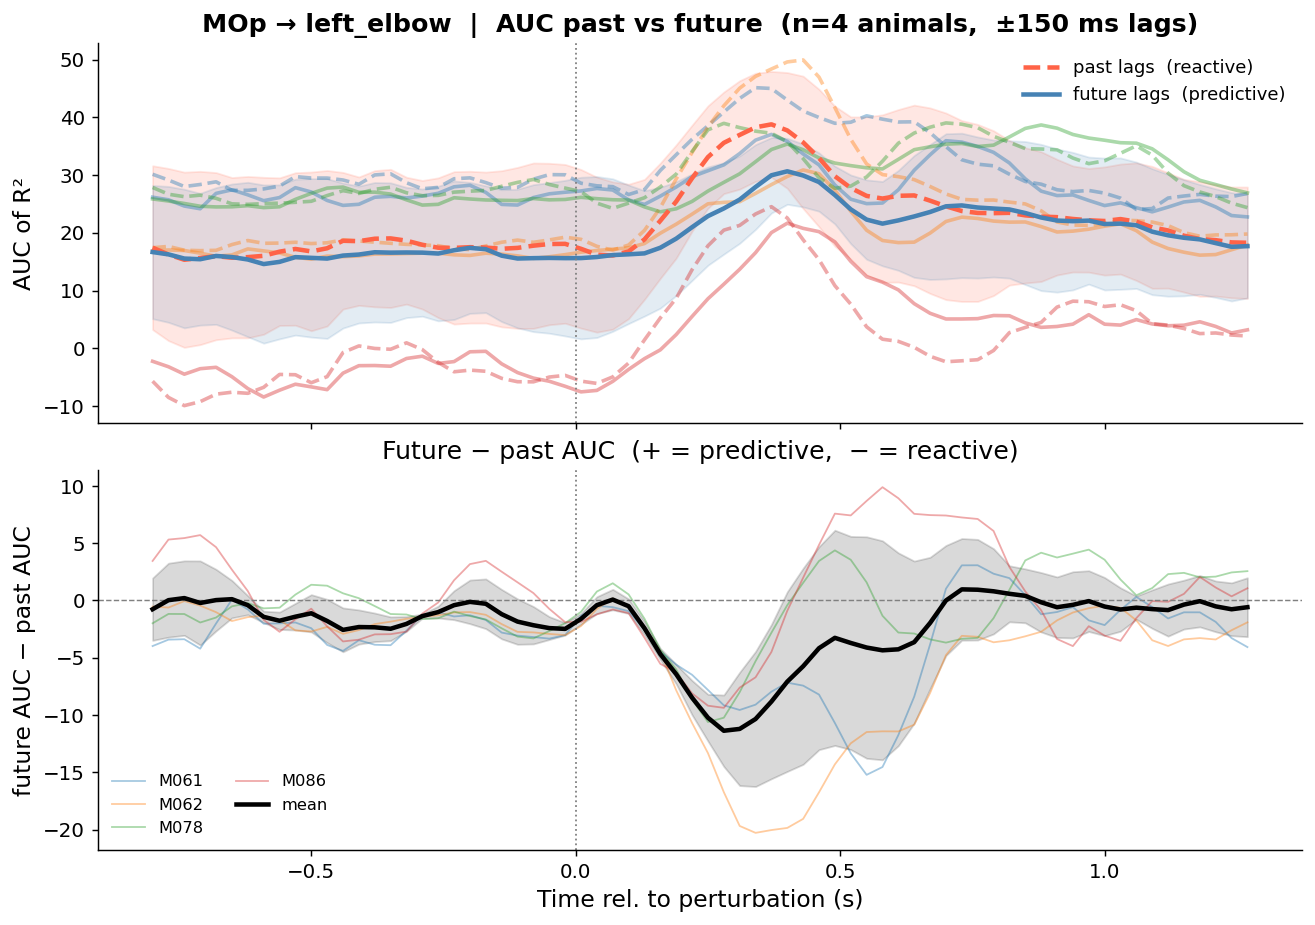

In [19]:
# ── AUC past vs future — all sessions, one figure ────────────────────────────
# For each time window, compute the area under the R²-vs-lag curve separately
# on the past (negative lags) and future (positive lags) sides.
# No baseline subtraction — raw AUC.

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_AUC_LAG_LIM_MS = 150
_cmap_a         = mpl.colormaps['tab10']
_animal_colors  = {a: _cmap_a(i) for i, a in enumerate(animals)}

# ── compute AUC per session ────────────────────────────────────────────────────
sess_auc = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _past_mask   = (_lags >= -_AUC_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _AUC_LAG_LIM_MS)

    _past_auc   = np.array([np.trapz(_res[ti].mean(-1)[_past_mask],   _lags[_past_mask])   for ti in _t])
    _future_auc = np.array([np.trapz(_res[ti].mean(-1)[_future_mask], _lags[_future_mask]) for ti in _t])
    _auc_diff   = _future_auc - _past_auc

    sess_auc[sess] = {'t': _t, 'past': _past_auc, 'future': _future_auc,
                      'diff': _auc_diff, 'animal': sess[:4]}

    print(f'{sess}: peak future AUC={_future_auc.max():.3f}  '
          f'peak past AUC={_past_auc.max():.3f}  '
          f'peak diff={_auc_diff.max():.3f} at t={_t[_auc_diff.argmax()]:.2f} s')

# ── average within animal ──────────────────────────────────────────────────────
_common_t = next(iter(sess_auc.values()))['t']
animal_auc = {}
for animal in animals:
    _s = [v for v in sess_auc.values() if v['animal'] == animal]
    animal_auc[animal] = {
        'past':   np.mean([s['past']   for s in _s], axis=0),
        'future': np.mean([s['future'] for s in _s], axis=0),
        'diff':   np.mean([s['diff']   for s in _s], axis=0),
    }

# grand mean ± SEM across animals
for key in ['past', 'future']:
    stack = np.array([animal_auc[a][key] for a in animals])
    animal_auc[f'mean_{key}'] = stack.mean(axis=0)
    animal_auc[f'sem_{key}']  = stack.std(axis=0) #/ np.sqrt(len(animals))

diff_stack = np.array([animal_auc[a]['diff'] for a in animals])
grand_mean = diff_stack.mean(axis=0)
grand_sem  = diff_stack.std(axis=0) #/ np.sqrt(len(animals))

# ── plot ───────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

    # ── top: past and future AUC ──────────────────────────────────────────
    ax = axes[0]
    for animal in animals:
        ax.plot(_common_t, animal_auc[animal]['past'],
                color=_animal_colors[animal], lw=2, alpha=0.4, ls='--')
        ax.plot(_common_t, animal_auc[animal]['future'],
                color=_animal_colors[animal], lw=2, alpha=0.4)

    ax.plot(_common_t, animal_auc['mean_past'],   color='tomato',    lw=2.5, ls='--', label='past lags  (reactive)')
    ax.plot(_common_t, animal_auc['mean_future'],  color='steelblue', lw=2.5, ls='-',  label='future lags  (predictive)')
    ax.fill_between(_common_t,
                    animal_auc['mean_past']   - animal_auc['sem_past'],
                    animal_auc['mean_past']   + animal_auc['sem_past'],
                    color='tomato', alpha=0.15)
    ax.fill_between(_common_t,
                    animal_auc['mean_future'] - animal_auc['sem_future'],
                    animal_auc['mean_future'] + animal_auc['sem_future'],
                    color='steelblue', alpha=0.15)
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_ylabel('AUC of R²')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  AUC past vs future  '
                 f'(n={len(animals)} animals,  ±{_AUC_LAG_LIM_MS} ms lags)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=10)

    # ── bottom: future − past ─────────────────────────────────────────────
    ax = axes[1]
    for animal in animals:
        ax.plot(_common_t, animal_auc[animal]['diff'],
                color=_animal_colors[animal], lw=1.0, alpha=0.4, label=animal)
    ax.plot(_common_t, grand_mean, color='k', lw=2.5, zorder=5, label='mean')
    ax.fill_between(_common_t,
                    grand_mean - grand_sem,
                    grand_mean + grand_sem,
                    color='k', alpha=0.15)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean > 0), color='steelblue', alpha=0.15)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean < 0), color='tomato', alpha=0.15)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('future AUC − past AUC')
    ax.set_title('Future − past AUC  (+ = predictive,  − = reactive)')
    ax.legend(frameon=False, fontsize=9, ncol=2)

    plt.show()

In [248]:
# ── compute AUC per session ────────────────────────────────────────────────────
sess_auc = {}
_AUC_LAG_LIM_MS = 200
for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _past_mask   = (_lags >= -_AUC_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _AUC_LAG_LIM_MS)
    _total_mask = (_lags >= -_AUC_LAG_LIM_MS) & (_lags <= _AUC_LAG_LIM_MS)


    _past_auc   = np.array([np.trapz(_res[ti].mean(-1)[_past_mask],   _lags[_past_mask])   for ti in _t])
    _future_auc = np.array([np.trapz(_res[ti].mean(-1)[_future_mask], _lags[_future_mask]) for ti in _t])
    _auc_diff   = _future_auc - _past_auc
    _auc_total = np.array([np.trapz(_res[ti].mean(-1)[_total_mask],   _lags[_total_mask])   for ti in _t])
    _r2_lag0    = np.array([_res[ti].mean(-1)[_t0]   for ti in _t])
    _peak_r2    = np.array([_res[ti].mean(-1).max()  for ti in _t])

    sess_auc[sess] = {'t': _t, 'past': _past_auc, 'future': _future_auc, 'total': _auc_total,
                      'r2_0': _r2_lag0, 'peak_r2': _peak_r2,
                      'diff': _auc_diff, 'animal': sess[:4]}

Peak future−past (bl-sub): -10.1802  at t=0.28 s


/tmp/ipykernel_1002535/1366484053.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=10)


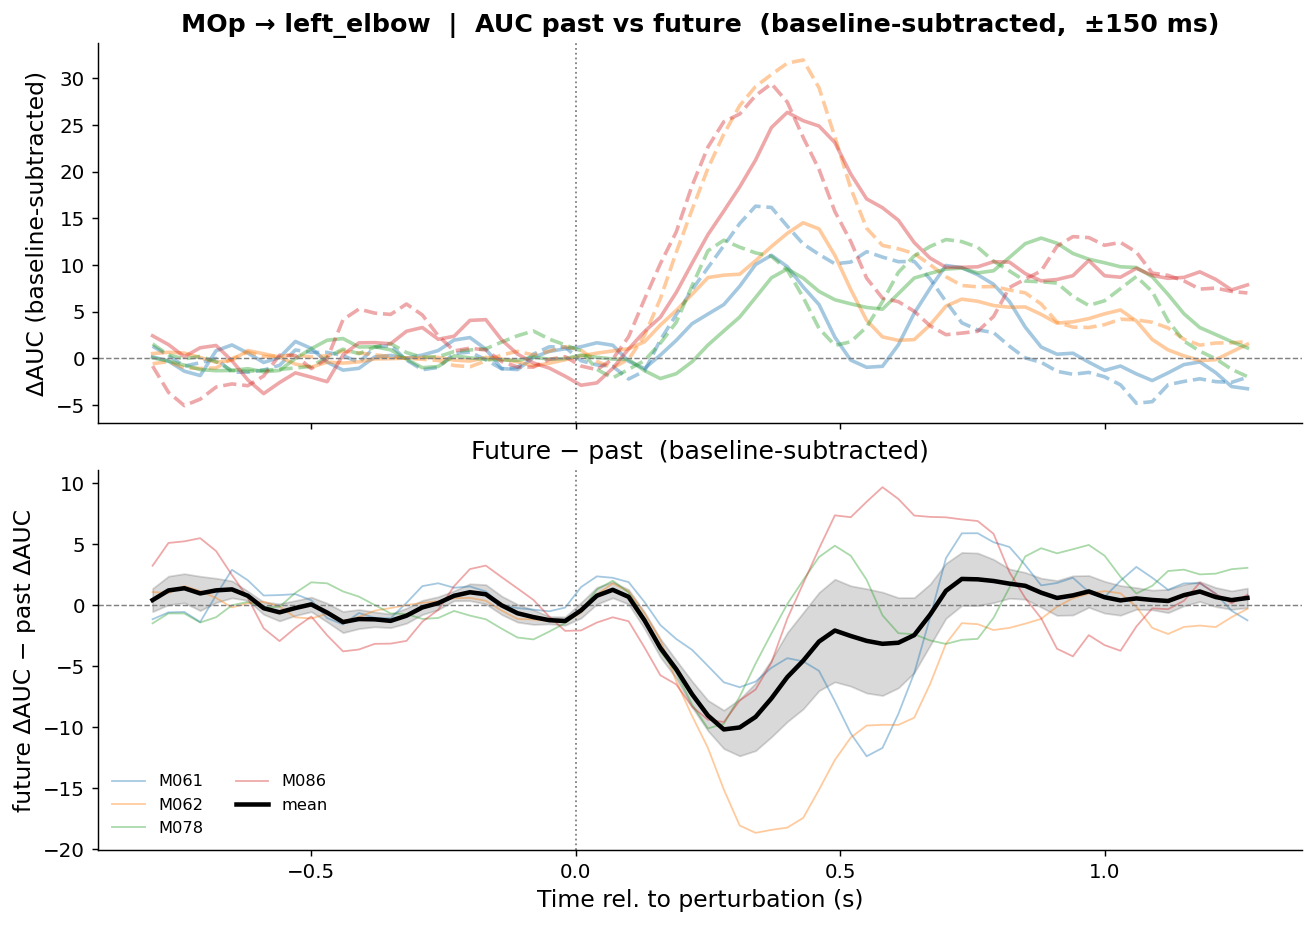

In [21]:
# ── AUC past vs future (baseline-subtracted) — all sessions, one figure ───────
# For each session, subtract the mean AUC during the baseline window from the
# past and future traces. Y-axis = change in AUC relative to pre-perturbation.

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_AUC_LAG_LIM_MS = 150
_cmap_a         = mpl.colormaps['tab10']
_animal_colors  = {a: _cmap_a(i) for i, a in enumerate(animals)}

sess_auc_bs = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _bl_mask     = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _past_mask   = (_lags >= -_AUC_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _AUC_LAG_LIM_MS)

    _past_auc   = np.array([np.trapz(_res[ti].mean(-1)[_past_mask],   _lags[_past_mask])   for ti in _t])
    _future_auc = np.array([np.trapz(_res[ti].mean(-1)[_future_mask], _lags[_future_mask]) for ti in _t])

    # subtract baseline mean
    _past_auc_bs   = _past_auc   - _past_auc[_bl_mask].mean()
    _future_auc_bs = _future_auc - _future_auc[_bl_mask].mean()
    _diff_bs       = _future_auc_bs - _past_auc_bs

    sess_auc_bs[sess] = {'t': _t, 'past': _past_auc_bs, 'future': _future_auc_bs,
                         'diff': _diff_bs, 'animal': sess[:4]}

# ── average within animal ──────────────────────────────────────────────────────
_common_t = next(iter(sess_auc_bs.values()))['t']
animal_auc_bs = {}
for animal in animals:
    _s = [v for v in sess_auc_bs.values() if v['animal'] == animal]
    animal_auc_bs[animal] = {
        'past':   np.mean([s['past']   for s in _s], axis=0),
        'future': np.mean([s['future'] for s in _s], axis=0),
        'diff':   np.mean([s['diff']   for s in _s], axis=0),
    }

for key in ['past', 'future']:
    stack = np.array([animal_auc_bs[a][key] for a in animals])
    animal_auc_bs[f'mean_{key}'] = stack.mean(axis=0)
    animal_auc_bs[f'sem_{key}']  = stack.std(axis=0) / np.sqrt(len(animals))

diff_stack = np.array([animal_auc_bs[a]['diff'] for a in animals])
grand_mean = diff_stack.mean(axis=0)
grand_sem  = diff_stack.std(axis=0) / np.sqrt(len(animals))

print(f'Peak future−past (bl-sub): {grand_mean[np.abs(grand_mean).argmax()]:.4f}  '
      f'at t={_common_t[np.abs(grand_mean).argmax()]:.2f} s')

with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

    ax = axes[0]
    for animal in animals:
        ax.plot(_common_t, animal_auc_bs[animal]['past'],
                color=_animal_colors[animal], lw=2.0, alpha=0.4, ls='--')
        ax.plot(_common_t, animal_auc_bs[animal]['future'],
                color=_animal_colors[animal], lw=2.0, alpha=0.4)
    # ax.plot(_common_t, animal_auc_bs['mean_past'],   color='tomato',    lw=2.5, ls='--', label='past  (reactive)')
    # ax.plot(_common_t, animal_auc_bs['mean_future'], color='steelblue', lw=2.5, ls='-',  label='future  (predictive)')
    # ax.fill_between(_common_t,
    #                 animal_auc_bs['mean_past']   - animal_auc_bs['sem_past'],
    #                 animal_auc_bs['mean_past']   + animal_auc_bs['sem_past'],
    #                 color='tomato', alpha=0.15)
    # ax.fill_between(_common_t,
    #                 animal_auc_bs['mean_future'] - animal_auc_bs['sem_future'],
    #                 animal_auc_bs['mean_future'] + animal_auc_bs['sem_future'],
    #                 color='steelblue', alpha=0.15)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_ylabel('ΔAUC (baseline-subtracted)')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  AUC past vs future  (baseline-subtracted,  ±{_AUC_LAG_LIM_MS} ms)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=10)

    ax = axes[1]
    for animal in animals:
        ax.plot(_common_t, animal_auc_bs[animal]['diff'],
                color=_animal_colors[animal], lw=1.0, alpha=0.4, label=animal)
    ax.plot(_common_t, grand_mean, color='k', lw=2.5, zorder=5, label='mean')
    ax.fill_between(_common_t, grand_mean - grand_sem, grand_mean + grand_sem,
                    color='k', alpha=0.15)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean > 0), color='steelblue', alpha=0.15)
    # ax.fill_between(_common_t, grand_mean, 0,
    #                 where=(grand_mean < 0), color='tomato', alpha=0.15)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('future ΔAUC − past ΔAUC')
    ax.set_title('Future − past  (baseline-subtracted)')
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.show()

M061  past peak: 0.340 s  |  future peak: 0.370 s  |  lead: 0.030 s
M062  past peak: 0.430 s  |  future peak: 0.430 s  |  lead: 0.000 s
M078  past peak: 0.700 s  |  future peak: 0.880 s  |  lead: 0.180 s
M086  past peak: 0.370 s  |  future peak: 0.400 s  |  lead: 0.030 s


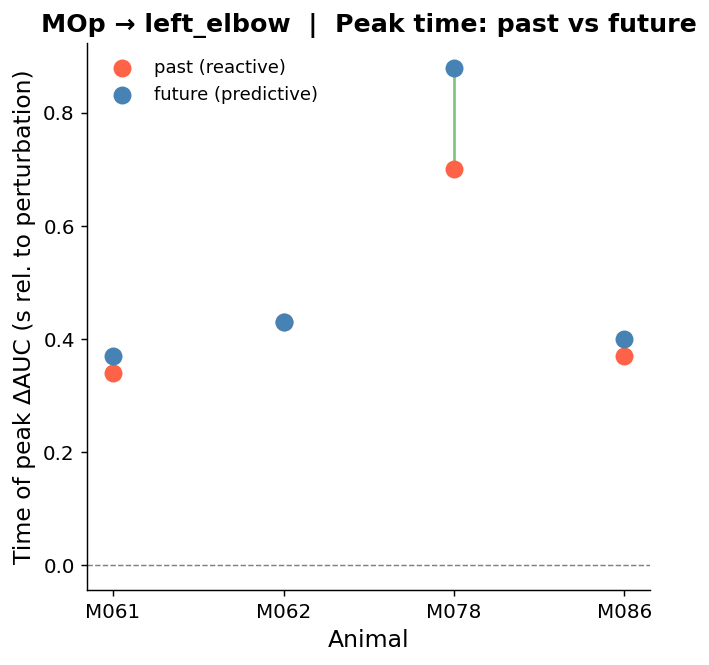

In [22]:
# ── Peak times of past vs future AUC per animal ───────────────────────────────
# For each animal, find the time of peak ΔAUC in the post-perturbation window
# for past (reactive) and future (predictive) separately.
# Animals on x-axis; past and future peak times connected per animal.

_post_mask = _common_t > 0

_peak_times = {}
for animal in animals:
    _past_post   = animal_auc_bs[animal]['past'][_post_mask]
    _future_post = animal_auc_bs[animal]['future'][_post_mask]
    _t_post      = _common_t[_post_mask]

    _peak_times[animal] = {
        'past':   _t_post[np.argmax(_past_post)],
        'future': _t_post[np.argmax(_future_post)],
    }
    print(f"{animal}  past peak: {_peak_times[animal]['past']:.3f} s  |  "
          f"future peak: {_peak_times[animal]['future']:.3f} s  |  "
          f"lead: {_peak_times[animal]['future'] - _peak_times[animal]['past']:.3f} s")

with mpl.rc_context(_PRES_RC):
    fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

    x = np.arange(len(animals))
    for xi, animal in enumerate(animals):
        t_past   = _peak_times[animal]['past']
        t_future = _peak_times[animal]['future']
        ax.plot([xi, xi], [t_past, t_future], color=_animal_colors[animal],
                lw=1.5, alpha=0.6, zorder=1)
        ax.scatter(xi, t_past,   color='tomato',    s=80, zorder=2,
                   label='past (reactive)'   if xi == 0 else None)
        ax.scatter(xi, t_future, color='steelblue', s=80, zorder=2,
                   label='future (predictive)' if xi == 0 else None)

    ax.set_xticks(x)
    ax.set_xticklabels(animals)
    ax.set_xlabel('Animal')
    ax.set_ylabel('Time of peak ΔAUC (s rel. to perturbation)')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  Peak time: past vs future',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=10)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    plt.show()


Peak normalised bl-sub diff: 14.4623  at t=-0.14 s


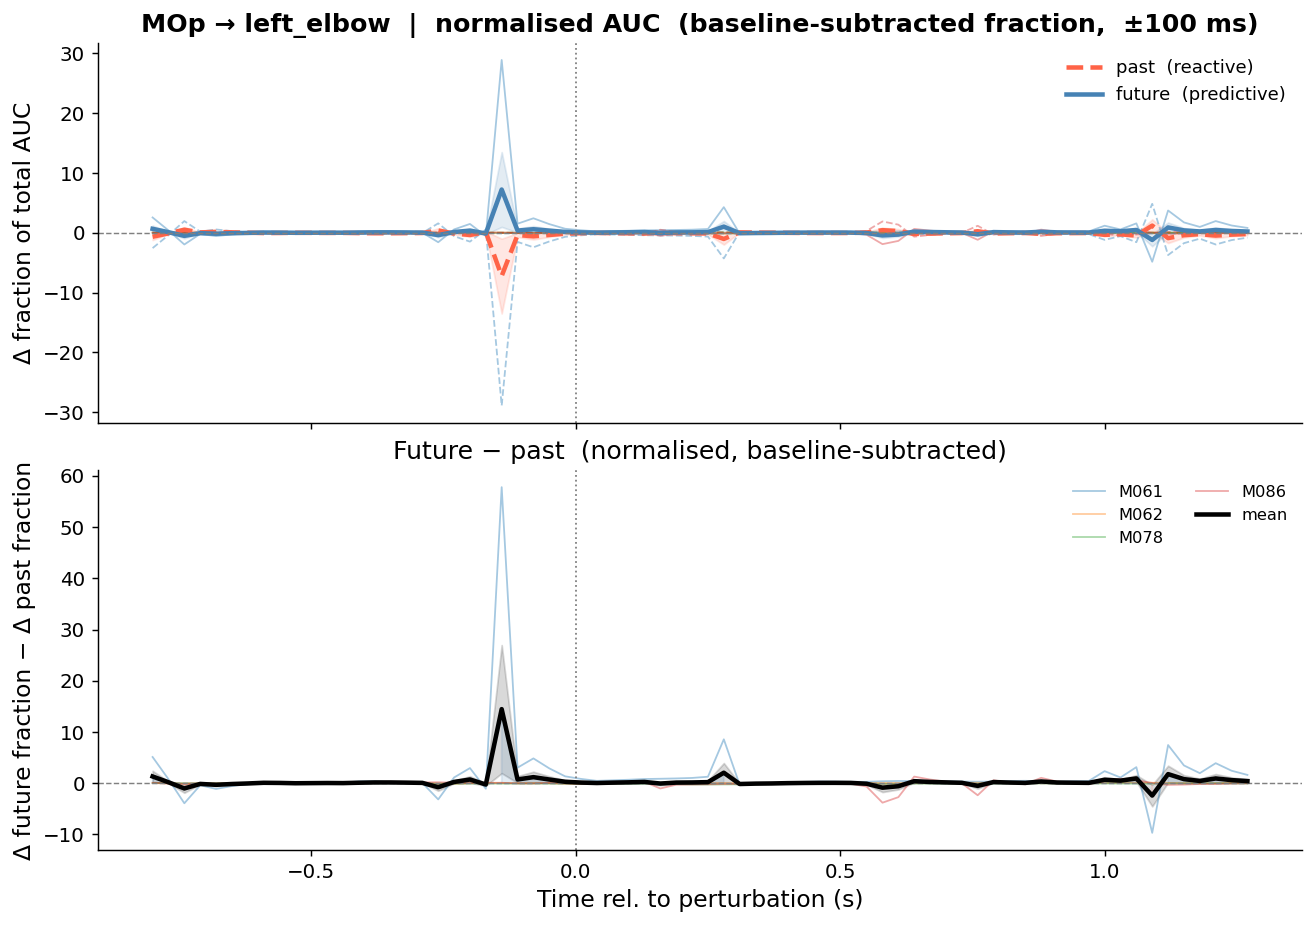

In [36]:
# ── Normalised AUC past vs future (baseline-subtracted fraction) ──────────────
# Compute past/future as fraction of total AUC, then subtract the baseline
# fraction. Y-axis = deviation from resting asymmetry (~0 at baseline).

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_AUC_LAG_LIM_MS = 100
_cmap_a         = mpl.colormaps['tab10']
_animal_colors  = {a: _cmap_a(i) for i, a in enumerate(animals)}

sess_auc_norm_bs = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _bl_mask     = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _past_mask   = (_lags >= -_AUC_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _AUC_LAG_LIM_MS)

    _past_auc   = np.array([np.trapz(_res[ti].mean(-1)[_past_mask],   _lags[_past_mask])   for ti in _t])
    _future_auc = np.array([np.trapz(_res[ti].mean(-1)[_future_mask], _lags[_future_mask]) for ti in _t])
    _total_auc  = _past_auc + _future_auc

    _past_frac   = _past_auc   / _total_auc
    _future_frac = _future_auc / _total_auc

    # subtract baseline fraction
    _past_frac_bs   = _past_frac   - _past_frac[_bl_mask].mean()
    _future_frac_bs = _future_frac - _future_frac[_bl_mask].mean()
    _diff_bs        = _future_frac_bs - _past_frac_bs

    sess_auc_norm_bs[sess] = {'t': _t, 'past': _past_frac_bs, 'future': _future_frac_bs,
                              'diff': _diff_bs, 'animal': sess[:4]}

# ── average within animal ──────────────────────────────────────────────────────
_common_t = next(iter(sess_auc_norm_bs.values()))['t']
animal_auc_norm_bs = {}
for animal in animals:
    _s = [v for v in sess_auc_norm_bs.values() if v['animal'] == animal]
    animal_auc_norm_bs[animal] = {
        'past':   np.mean([s['past']   for s in _s], axis=0),
        'future': np.mean([s['future'] for s in _s], axis=0),
        'diff':   np.mean([s['diff']   for s in _s], axis=0),
    }

for key in ['past', 'future']:
    stack = np.array([animal_auc_norm_bs[a][key] for a in animals])
    animal_auc_norm_bs[f'mean_{key}'] = stack.mean(axis=0)
    animal_auc_norm_bs[f'sem_{key}']  = stack.std(axis=0) / np.sqrt(len(animals))

diff_stack = np.array([animal_auc_norm_bs[a]['diff'] for a in animals])
grand_mean = diff_stack.mean(axis=0)
grand_sem  = diff_stack.std(axis=0) / np.sqrt(len(animals))

print(f'Peak normalised bl-sub diff: {grand_mean[np.abs(grand_mean).argmax()]:.4f}  '
      f'at t={_common_t[np.abs(grand_mean).argmax()]:.2f} s')

with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

    ax = axes[0]
    for animal in animals:
        ax.plot(_common_t, animal_auc_norm_bs[animal]['past'],
                color=_animal_colors[animal], lw=1.0, alpha=0.4, ls='--')
        ax.plot(_common_t, animal_auc_norm_bs[animal]['future'],
                color=_animal_colors[animal], lw=1.0, alpha=0.4)
    ax.plot(_common_t, animal_auc_norm_bs['mean_past'],   color='tomato',    lw=2.5, ls='--', label='past  (reactive)')
    ax.plot(_common_t, animal_auc_norm_bs['mean_future'], color='steelblue', lw=2.5, ls='-',  label='future  (predictive)')
    ax.fill_between(_common_t,
                    animal_auc_norm_bs['mean_past']   - animal_auc_norm_bs['sem_past'],
                    animal_auc_norm_bs['mean_past']   + animal_auc_norm_bs['sem_past'],
                    color='tomato', alpha=0.15)
    ax.fill_between(_common_t,
                    animal_auc_norm_bs['mean_future'] - animal_auc_norm_bs['sem_future'],
                    animal_auc_norm_bs['mean_future'] + animal_auc_norm_bs['sem_future'],
                    color='steelblue', alpha=0.15)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_ylabel('Δ fraction of total AUC')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  normalised AUC  (baseline-subtracted fraction,  ±{_AUC_LAG_LIM_MS} ms)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=10)

    ax = axes[1]
    for animal in animals:
        ax.plot(_common_t, animal_auc_norm_bs[animal]['diff'],
                color=_animal_colors[animal], lw=1.0, alpha=0.4, label=animal)
    ax.plot(_common_t, grand_mean, color='k', lw=2.5, zorder=5, label='mean')
    ax.fill_between(_common_t, grand_mean - grand_sem, grand_mean + grand_sem,
                    color='k', alpha=0.15)
    ax.fill_between(_common_t, grand_mean, 0,
                    where=(grand_mean > 0), color='steelblue', alpha=0.15)
    ax.fill_between(_common_t, grand_mean, 0,
                    where=(grand_mean < 0), color='tomato', alpha=0.15)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Δ future fraction − Δ past fraction')
    ax.set_title('Future − past  (normalised, baseline-subtracted)')
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.show()

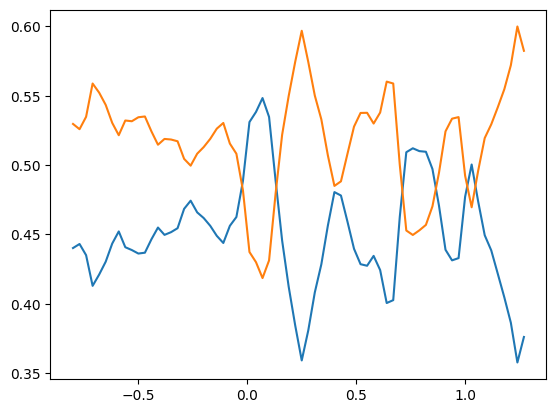

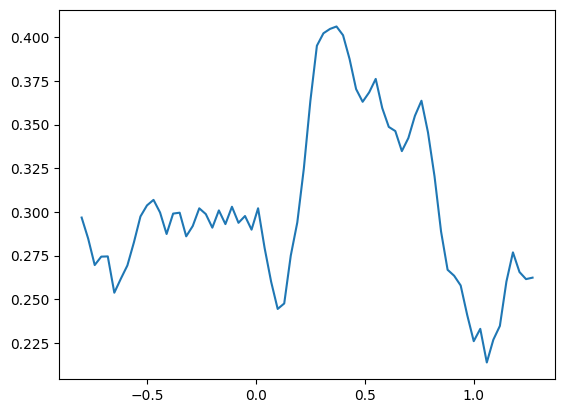

In [162]:
# plt.plot(_t, sess_auc['M061_2025_03_06_14_00']['total'])
plt.plot(_t, sess_auc['M061_2025_03_06_14_00']['future'] / sess_auc['M061_2025_03_06_14_00']['total'])
plt.plot(_t, sess_auc['M061_2025_03_06_14_00']['past'] / sess_auc['M061_2025_03_06_14_00']['total'])

plt.show()

plt.figure()
plt.plot(_t, sess_auc['M061_2025_03_06_14_00']['peak_r2'])
plt.show()

M061_2025_03_05_14_00: var(dev_diff | t>0) = 0.40595
M061_2025_03_06_14_00: var(dev_diff | t>0) = 0.09144
M062_2025_03_20_14_00: var(dev_diff | t>0) = 0.09275
M062_2025_03_21_14_00: var(dev_diff | t>0) = 0.13765
M078_2025_08_06_15_00: var(dev_diff | t>0) = 0.05964


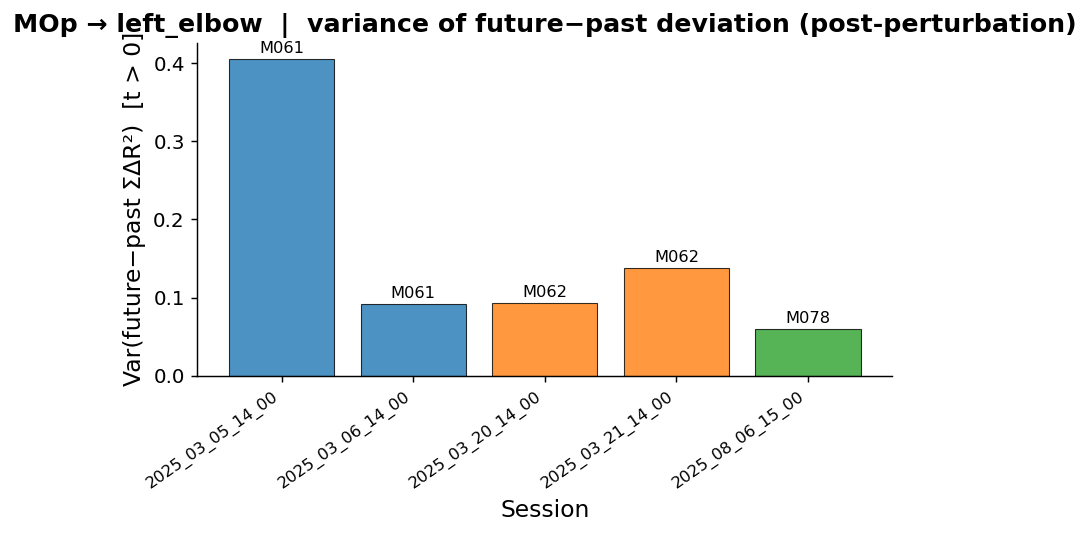

In [251]:
# ── Variance of future−past deviation over time — one value per session ───────
# For each session, compute the variance of the dev_diff signal across time bins
# (post-perturbation only: t > 0). A session with a strong, consistent asymmetry
# will have high variance; a flat/noisy session will have low variance.

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

_DEV_LAG_LIM_MS = 100

sess_var = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _res  = _raw[KEYPOINT]
    _t    = np.array(sorted(_res.keys()))

    _bl_mask     = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _bl_mean     = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
    _past_mask   = (_lags >= -_DEV_LAG_LIM_MS) & (_lags < 0)
    _future_mask = (_lags > 0) & (_lags <= _DEV_LAG_LIM_MS)

    _past_dev   = np.array([np.sum(np.abs(_res[ti].mean(-1)[_past_mask]   - _bl_mean[_past_mask]))   for ti in _t])
    _future_dev = np.array([np.sum(np.abs(_res[ti].mean(-1)[_future_mask] - _bl_mean[_future_mask])) for ti in _t])
    _dev_diff   = _future_dev - _past_dev

    # restrict to post-perturbation
    _post_mask = _t > 0
    _var = np.var(_dev_diff[_post_mask])

    sess_var[sess] = {'var': _var, 'animal': sess[:4]}
    print(f'{sess}: var(dev_diff | t>0) = {_var:.5f}')

# ── plot ───────────────────────────────────────────────────────────────────────
_sessions  = list(sess_var.keys())
_variances = [sess_var[s]['var'] for s in _sessions]
_anim_labs = [sess_var[s]['animal'] for s in _sessions]
_colors    = [_cmap_a(animals.index(a)) for a in _anim_labs]
_x         = np.arange(len(_sessions))

with mpl.rc_context(_PRES_RC):
    fig, ax = plt.subplots(figsize=(max(6, len(_sessions) * 1.2), 4), constrained_layout=True)

    ax.bar(_x, _variances, color=_colors, alpha=0.8, edgecolor='k', linewidth=0.6)

    # label each bar with animal id
    for xi, (var, lab) in enumerate(zip(_variances, _anim_labs)):
        ax.text(xi, var + max(_variances) * 0.01, lab, ha='center', va='bottom', fontsize=9)

    ax.set_xticks(_x)
    ax.set_xticklabels([s[5:] for s in _sessions], rotation=35, ha='right', fontsize=9)
    ax.set_xlabel('Session')
    ax.set_ylabel('Var(future−past ΣΔR²)  [t > 0]')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  variance of future−past deviation (post-perturbation)',
                 fontweight='bold')
    plt.show()

M061_2025_03_06_14_00: peak drift = 3.8 ms  valid bins = 70/70  (R²>0.02 gate)
M062_2025_03_20_14_00: peak drift = 17.4 ms  valid bins = 70/70  (R²>0.02 gate)
M062_2025_03_21_14_00: peak drift = 23.5 ms  valid bins = 70/70  (R²>0.02 gate)
M078_2025_08_06_15_00: peak drift = 29.5 ms  valid bins = 70/70  (R²>0.02 gate)
M086_2025_12_10_15_00: peak drift = nan ms  valid bins = 0/70  (R²>0.02 gate)

Grand mean peak: 8.0 ms  at t=0.46 s  (70/70 bins with ≥2 animals)


/tmp/ipykernel_1016917/4121369254.py:58: RuntimeWarning: Mean of empty slice
  _drift -= np.nanmean(_drift[_bl_mask])
/tmp/ipykernel_1016917/4121369254.py:61: RuntimeWarning: All-NaN slice encountered
  print(f'{sess}: peak drift = {np.nanmax(np.abs(_drift)):.1f} ms  '


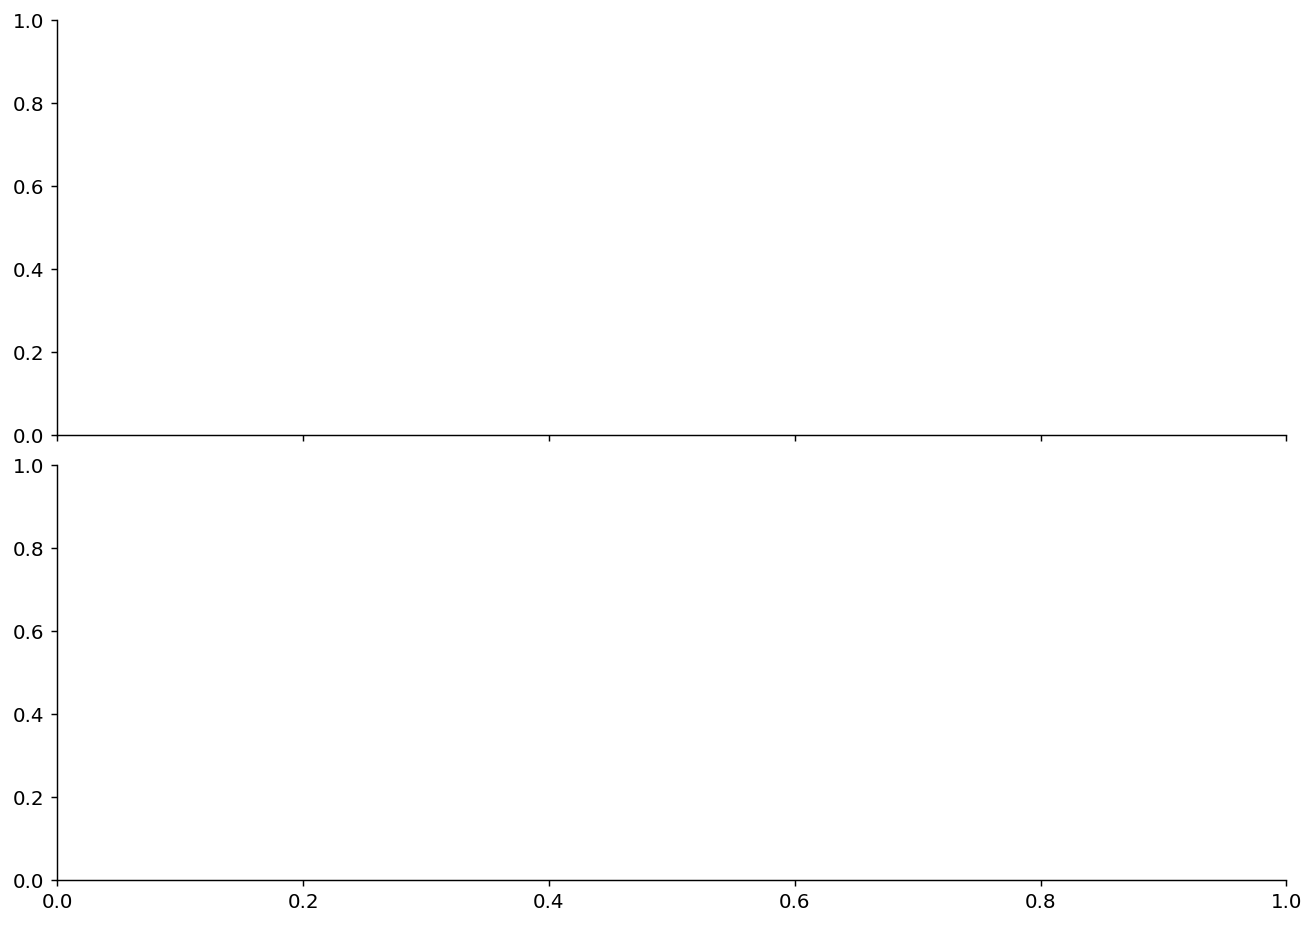

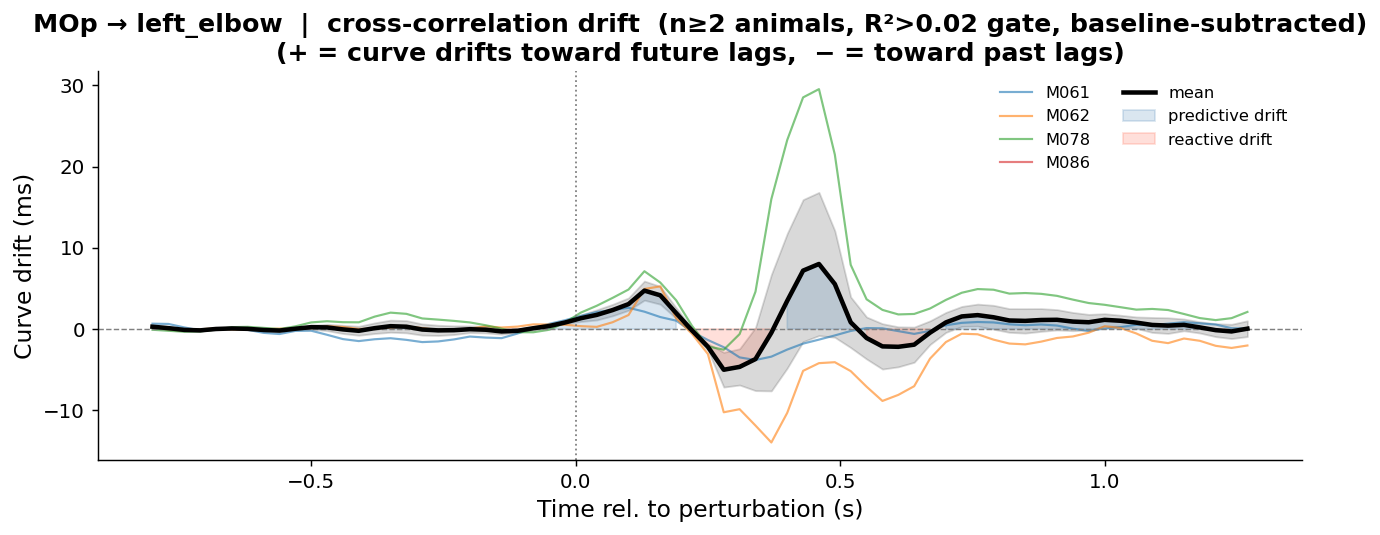

In [17]:
# ── Cross-correlation drift — all sessions, one figure ────────────────────────
from scipy.signal import correlate

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

R2_GATE    = 0.02
MIN_ANIMALS = 2
_cmap_a        = mpl.colormaps['tab10']
_animal_colors = {a: _cmap_a(i) for i, a in enumerate(animals)}

def _xcorr_drift(curve, baseline, lag_step):
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    pk = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * lag_step - (len(curve) - 1) * lag_step
    return (pk - (len(curve) - 1)) * lag_step

def _safe_mean_sem(stack, min_n=MIN_ANIMALS):
    n_valid = (~np.isnan(stack)).sum(axis=0)
    mean = np.full(stack.shape[1], np.nan)
    sem  = np.full(stack.shape[1], np.nan)
    mask = n_valid >= min_n
    if mask.any():
        mean[mask] = np.nanmean(stack[:, mask], axis=0)
        sem[mask]  = np.nanstd( stack[:, mask], axis=0) / np.sqrt(n_valid[mask])
    return mean, sem

sess_drift = {}

for sess in session_metrics:
    with open(RESULTS_DIR / f'lagged_dec_{AREA}_{sess}.pkl', 'rb') as f:
        _raw = pickle.load(f)

    _lags     = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else lags_ms
    _lag_step = _lags[1] - _lags[0]
    _res      = _raw[KEYPOINT]
    _t        = np.array(sorted(_res.keys()))

    _bl_mask = (_t >= BASELINE_S[0]) & (_t < BASELINE_S[1])
    _bl_mean = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
    _peak_r2 = np.array([_res[ti].mean(-1).max() for ti in _t])

    _drift = np.array([_xcorr_drift(_res[ti].mean(-1), _bl_mean, _lag_step) for ti in _t])
    _drift[_peak_r2 < R2_GATE] = np.nan
    _drift -= np.nanmean(_drift[_bl_mask])

    n_valid = (~np.isnan(_drift)).sum()
    print(f'{sess}: peak drift = {np.nanmax(np.abs(_drift)):.1f} ms  '
          f'valid bins = {n_valid}/{len(_t)}  (R²>{R2_GATE} gate)')

    sess_drift[sess] = {'t': _t, 'drift': _drift, 'animal': sess[:4]}

# ── average within animal ──────────────────────────────────────────────────────
_common_t = next(iter(sess_drift.values()))['t']
animal_drift = {}
for animal in animals:
    _s = [v['drift'] for v in sess_drift.values() if v['animal'] == animal]
    _stack = np.array(_s)
    animal_drift[animal], _ = _safe_mean_sem(_stack, min_n=1)

grand_mean, grand_sem = _safe_mean_sem(np.array(list(animal_drift.values())))

print(f'\nGrand mean peak: {np.nanmax(np.abs(grand_mean)):.1f} ms  '
      f'at t={_common_t[np.nanargmax(np.abs(grand_mean))]:.2f} s  '
      f'({(~np.isnan(grand_mean)).sum()}/{len(_common_t)} bins with ≥{MIN_ANIMALS} animals)')

with mpl.rc_context(_PRES_RC):
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    for animal in animals:
        ax.plot(_common_t, animal_drift[animal],
                color=_animal_colors[animal], lw=1.2, alpha=0.6, label=animal)
    ax.plot(_common_t, grand_mean, color='k', lw=2.5, zorder=5, label='mean')
    ax.fill_between(_common_t, grand_mean - grand_sem, grand_mean + grand_sem,
                    color='k', alpha=0.15)
    ax.fill_between(_common_t, grand_mean, 0,
                    where=(grand_mean > 0), color='steelblue', alpha=0.2, label='predictive drift')
    ax.fill_between(_common_t, grand_mean, 0,
                    where=(grand_mean < 0), color='tomato',    alpha=0.2, label='reactive drift')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Curve drift (ms)')
    ax.set_title(f'{AREA} → {KEYPOINT}  |  cross-correlation drift  '
                 f'(n≥{MIN_ANIMALS} animals, R²>{R2_GATE} gate, baseline-subtracted)\n'
                 f'(+ = curve drifts toward future lags,  − = toward past lags)',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.show()

  [20 PCs] M061_2025_03_06_14_00: valid bins = 70/70  (peak search ±150 ms)
  [20 PCs] M062_2025_03_20_14_00: valid bins = 70/70  (peak search ±150 ms)
  [20 PCs] M062_2025_03_21_14_00: valid bins = 70/70  (peak search ±150 ms)
  [20 PCs] M078_2025_08_06_15_00: valid bins = 70/70  (peak search ±150 ms)
  [All PCs] M061_2025_03_06_14_00: valid bins = 70/70  (peak search ±150 ms)
  [All PCs] M062_2025_03_20_14_00: valid bins = 70/70  (peak search ±150 ms)
  [All PCs] M062_2025_03_21_14_00: valid bins = 70/70  (peak search ±150 ms)
  [All PCs] M078_2025_08_06_15_00: valid bins = 70/70  (peak search ±150 ms)
20 PCs: 4 sessions, 3 animals contributing
  grand mean peak drift = 8.0 ms at t=0.46 s
All PCs: 4 sessions, 3 animals contributing
  grand mean peak drift = 38.5 ms at t=0.10 s


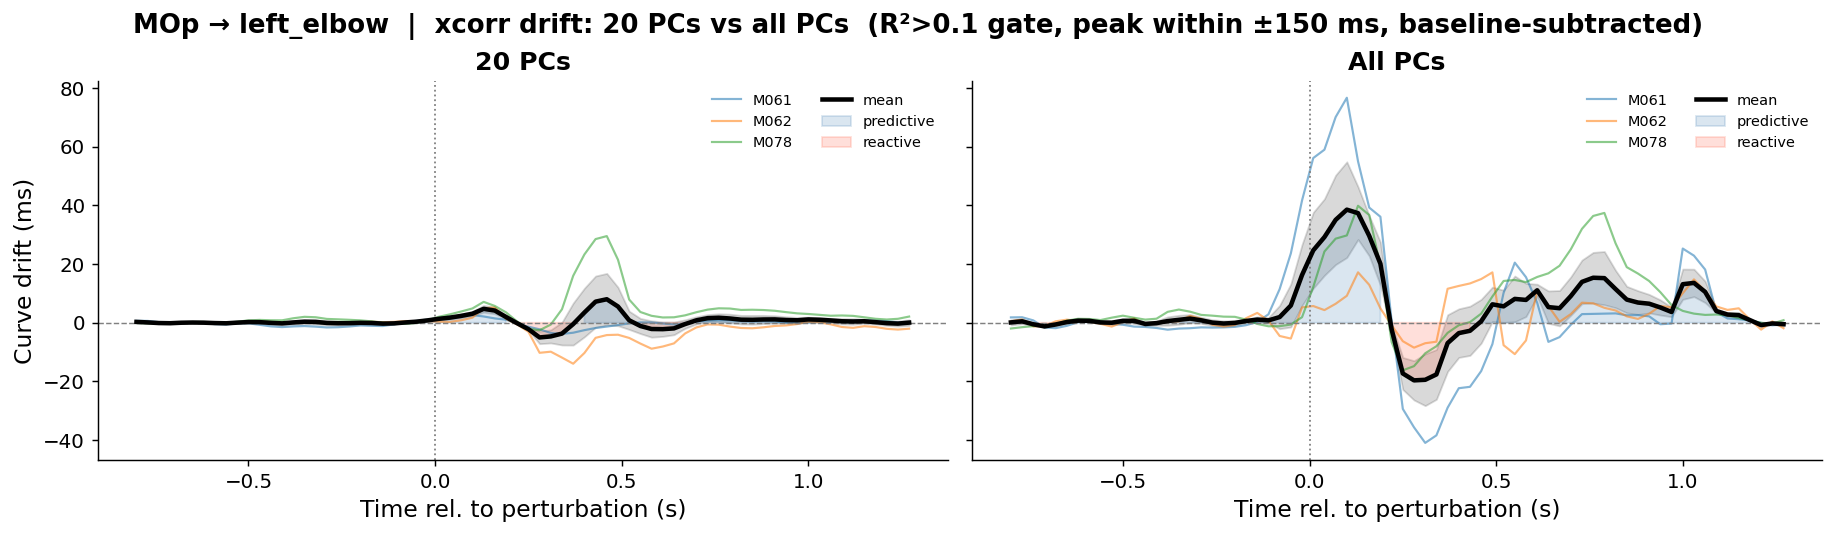

In [96]:
# ── XCorr drift comparison: 20 PCs vs all PCs ────────────────────────────────
# Self-contained: loads directly from both result folders.
# Sessions with 0 bins surviving the R²>0.1 gate are skipped entirely.

from pathlib import Path
from scipy.signal import correlate
import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

_CMP_SESSIONS = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
]

_DIRS = {
    '20 PCs':   Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs':  Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_CMP_R2_GATE    = 0.1
_CMP_MIN_N      = 2
_CMP_BASELINE   = (-1.0, -0.5)   # s
_CMP_LAG_LIM_MS = 150             # ms — peak-finding window for xcorr

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

def _cmp_xcorr(curve, baseline, lags):
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    lag_step = lags[1] - lags[0]
    offsets  = np.arange(-(len(lags) - 1), len(lags)) * lag_step
    win      = np.abs(offsets) <= _CMP_LAG_LIM_MS
    pk_in_win = np.argmax(xc[win])
    pk = np.where(win)[0][pk_in_win]   # index in full xcorr
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk-1], xc[pk], xc[pk+1]
        delta = 0.5 * (y0 - y2) / (y0 - 2*y1 + y2 + 1e-12)
        return (pk + delta) * lag_step - (len(lags) - 1) * lag_step
    return offsets[pk]

def _cmp_safe_mean_sem(stack, min_n=_CMP_MIN_N):
    n_valid = (~np.isnan(stack)).sum(axis=0)
    mean = np.full(stack.shape[1], np.nan)
    sem  = np.full(stack.shape[1], np.nan)
    mask = n_valid >= min_n
    if mask.any():
        mean[mask] = np.nanmean(stack[:, mask], axis=0)
        sem[mask]  = np.nanstd( stack[:, mask], axis=0) / np.sqrt(n_valid[mask])
    return mean, sem

# ── compute per-condition ──────────────────────────────────────────────────────
_cmp_animals = sorted(set(s[:4] for s in _CMP_SESSIONS))
_cmap_a      = mpl.colormaps['tab10']
_cmp_colors  = {a: _cmap_a(i) for i, a in enumerate(_cmp_animals)}

_results = {}   # {label: {sess: {'t', 'drift'}}}

for label, rdir in _DIRS.items():
    _sess_drift = {}
    for sess in _CMP_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            print(f'  [{label}] missing: {pkl_path.name}')
            continue

        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else None
        if _lags is None:
            print(f'  [{label}] {sess}: no _meta, skipping')
            continue

        if KEYPOINT not in _raw:
            print(f'  [{label}] {sess}: keypoint {KEYPOINT} not found')
            continue

        _res      = _raw[KEYPOINT]
        _t        = np.array(sorted(_res.keys()))
        _bl_mask  = (_t >= _CMP_BASELINE[0]) & (_t < _CMP_BASELINE[1])
        _bl_mean  = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
        _peak_r2  = np.array([_res[ti].mean(-1).max() for ti in _t])

        _drift = np.array([_cmp_xcorr(_res[ti].mean(-1), _bl_mean, _lags) for ti in _t])
        _drift[_peak_r2 < _CMP_R2_GATE] = np.nan

        n_valid = int((~np.isnan(_drift)).sum())
        print(f'  [{label}] {sess}: valid bins = {n_valid}/{len(_t)}  '
              f'(peak search ±{_CMP_LAG_LIM_MS} ms)')

        if n_valid == 0:
            print(f'    → skipping (all bins below R²>{_CMP_R2_GATE})')
            continue

        _drift -= np.nanmean(_drift[_bl_mask])
        _sess_drift[sess] = {'t': _t, 'drift': _drift, 'animal': sess[:4]}

    _results[label] = _sess_drift

# ── build per-animal and grand mean per condition ─────────────────────────────
_common_t = next(iter(next(iter(_results.values())).values()))['t']

_grand = {}
for label, _sess_drift in _results.items():
    _animal_drift = {}
    for animal in _cmp_animals:
        _s = [v['drift'] for v in _sess_drift.values() if v['animal'] == animal]
        if not _s:
            continue
        _stack = np.vstack(_s)
        _animal_drift[animal], _ = _cmp_safe_mean_sem(_stack, min_n=1)

    if len(_animal_drift) < 2:
        _grand[label] = (np.full(len(_common_t), np.nan), np.full(len(_common_t), np.nan), _animal_drift)
        continue

    _grand[label] = _cmp_safe_mean_sem(
        np.array(list(_animal_drift.values()))
    ) + (_animal_drift,)

# ── plot ──────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True, sharey=True)

    for ax, (label, (gm, gs, a_drift)) in zip(axes, _grand.items()):
        for animal, adrift in a_drift.items():
            ax.plot(_common_t, adrift, color=_cmp_colors[animal],
                    lw=1.2, alpha=0.55, label=animal)

        ax.plot(_common_t, gm, color='k', lw=2.5, zorder=5, label='mean')
        ax.fill_between(_common_t, gm - gs, gm + gs, color='k', alpha=0.15)
        ax.fill_between(_common_t, gm, 0, where=(gm > 0),
                        color='steelblue', alpha=0.2, label='predictive')
        ax.fill_between(_common_t, gm, 0, where=(gm < 0),
                        color='tomato',    alpha=0.2, label='reactive')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=1.0, ls=':')
        ax.set_xlabel('Time rel. to perturbation (s)')
        ax.set_title(f'{label}', fontweight='bold')
        ax.legend(frameon=False, fontsize=8, ncol=2)

        n_sess = len(_results[label])
        n_anim = len(a_drift)
        print(f'{label}: {n_sess} sessions, {n_anim} animals contributing')
        print(f'  grand mean peak drift = {np.nanmax(np.abs(gm)):.1f} ms '
              f'at t={_common_t[np.nanargmax(np.abs(gm))]:.2f} s')

    axes[0].set_ylabel('Curve drift (ms)')
    fig.suptitle(f'{AREA} → {KEYPOINT}  |  xcorr drift: 20 PCs vs all PCs  '
                 f'(R²>{_CMP_R2_GATE} gate, peak within ±{_CMP_LAG_LIM_MS} ms, baseline-subtracted)',
                 fontweight='bold')
    plt.show()


  20 PCs | M061_2025_03_06_14_00: peak R² = 0.382  baseline peak lag (±150ms) = -50 ms
  All PCs | M061_2025_03_06_14_00: peak R² = 0.387  baseline peak lag (±150ms) = -60 ms
  20 PCs | M062_2025_03_20_14_00: peak R² = 0.454  baseline peak lag (±150ms) = -50 ms
  All PCs | M062_2025_03_20_14_00: peak R² = 0.495  baseline peak lag (±150ms) = 0 ms
  20 PCs | M062_2025_03_21_14_00: peak R² = 0.390  baseline peak lag (±150ms) = -70 ms
  All PCs | M062_2025_03_21_14_00: peak R² = 0.508  baseline peak lag (±150ms) = -70 ms
  20 PCs | M078_2025_08_06_15_00: peak R² = 0.338  baseline peak lag (±150ms) = -100 ms
  All PCs | M078_2025_08_06_15_00: peak R² = 0.378  baseline peak lag (±150ms) = 20 ms


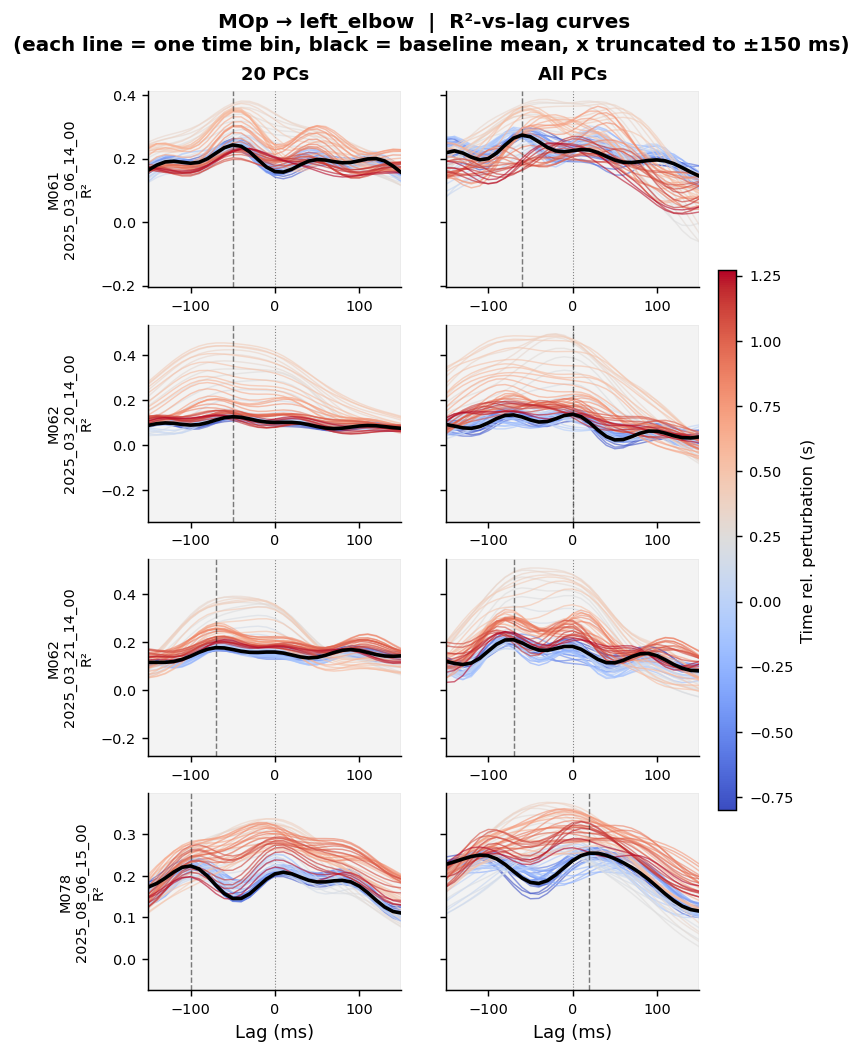

In [51]:
# ── R²-vs-lag curves: 20 PCs vs all PCs, per session ─────────────────────────
# Shows the actual curves from which xcorr drift is extracted.
# Rows = sessions, columns = conditions (20 PCs / all PCs).
# Each line = one time bin, coloured by time relative to perturbation.
# Thick black = baseline mean. Gray band = ±_CURVE_LAG_LIM_MS region.

from pathlib import Path
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

_CURVE_SESSIONS = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
]

_CURVE_DIRS = {
    '20 PCs':  Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs': Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_CURVE_BASELINE  = (-1.0, -0.5)   # s
_CURVE_LAG_LIM_MS = 150            # ms — x-axis truncation and gray band

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'figure.dpi':        130,
}

# ── load all data ─────────────────────────────────────────────────────────────
_curve_data = {}   # {label: {sess: {'lags', 't', 'curves', 'bl_mean'}}}

for label, rdir in _CURVE_DIRS.items():
    _curve_data[label] = {}
    for sess in _CURVE_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            continue
        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else None
        if _lags is None or KEYPOINT not in _raw:
            continue

        _res     = _raw[KEYPOINT]
        _t       = np.array(sorted(_res.keys()))
        _bl_mask = (_t >= _CURVE_BASELINE[0]) & (_t < _CURVE_BASELINE[1])
        _bl_mean = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
        _curves  = np.array([_res[ti].mean(-1) for ti in _t])   # (n_t, n_lags)

        _curve_data[label][sess] = {
            'lags':    _lags,
            't':       _t,
            'curves':  _curves,
            'bl_mean': _bl_mean,
        }

# ── determine layout ─────────────────────────────────────────────────────────
_valid_sessions = [s for s in _CURVE_SESSIONS
                   if any(s in _curve_data[lbl] for lbl in _CURVE_DIRS)]
_labels = list(_CURVE_DIRS.keys())
_n_rows = len(_valid_sessions)
_n_cols = len(_labels)

with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(
        _n_rows, _n_cols,
        figsize=(_n_cols * 3, _n_rows * 2),
        constrained_layout=True,
        sharey='row',
    )
    if _n_rows == 1:
        axes = axes[np.newaxis, :]

    # colour map: time relative to perturbation
    _t_ref  = next(iter(next(iter(_curve_data.values())).values()))['t']
    _t_min, _t_max = _t_ref.min(), _t_ref.max()
    _cmap_t = cm.coolwarm
    _norm_t = mpl.colors.Normalize(vmin=_t_min, vmax=_t_max)

    for row_i, sess in enumerate(_valid_sessions):
        for col_i, label in enumerate(_labels):
            ax = axes[row_i, col_i]

            if sess not in _curve_data[label]:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
                ax.set_visible(True)
                continue

            _d      = _curve_data[label][sess]
            _lags   = _d['lags']
            _t      = _d['t']
            _curves = _d['curves']
            _bl     = _d['bl_mean']

            ax.axvspan(-_CURVE_LAG_LIM_MS, _CURVE_LAG_LIM_MS,
                       color='lightgray', alpha=0.25, zorder=0)
            ax.axvline(0, color='gray', lw=0.6, ls=':')

            # one line per time bin, coloured by time
            for ti, (t_val, curve) in enumerate(zip(_t, _curves)):
                ax.plot(_lags, curve, color=_cmap_t(_norm_t(t_val)),
                        lw=0.8, alpha=0.6)

            # baseline mean
            ax.plot(_lags, _bl, color='k', lw=2, zorder=5, label='baseline')

            # peak of baseline (within truncation window)
            _win_mask = np.abs(_lags) <= _CURVE_LAG_LIM_MS
            pk_lag = _lags[_win_mask][np.argmax(_bl[_win_mask])]
            ax.axvline(pk_lag, color='k', lw=0.8, ls='--', alpha=0.5)

            peak_r2 = _curves.max()
            print(f'  {label} | {sess}: peak R² = {peak_r2:.3f}  '
                  f'baseline peak lag (±{_CURVE_LAG_LIM_MS}ms) = {pk_lag:.0f} ms')

            if row_i == 0:
                ax.set_title(label, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(f'{sess[:4]}\n{sess[5:]}\nR²', fontsize=8)
            if row_i == _n_rows - 1:
                ax.set_xlabel('Lag (ms)')

            ax.set_xlim(-_CURVE_LAG_LIM_MS, _CURVE_LAG_LIM_MS)

    # shared colorbar for time
    sm = cm.ScalarMappable(cmap=_cmap_t, norm=_norm_t)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                        shrink=0.6, pad=0.01, aspect=30)
    cbar.set_label('Time rel. perturbation (s)', fontsize=9)

    fig.suptitle(
        f'{AREA} → {KEYPOINT}  |  R²-vs-lag curves  '
        f'\n(each line = one time bin, black = baseline mean, '
        f'x truncated to ±{_CURVE_LAG_LIM_MS} ms)',
        fontweight='bold', fontsize=11,
    )
    plt.show()


  20 PCs | M061_2025_03_06_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  All PCs | M061_2025_03_06_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  20 PCs | M062_2025_03_20_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  All PCs | M062_2025_03_20_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  20 PCs | M062_2025_03_21_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  All PCs | M062_2025_03_21_14_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  20 PCs | M078_2025_08_06_15_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms
  All PCs | M078_2025_08_06_15_00: 70/70 bins above R²>0.1  baseline xcorr peak = 0 ms


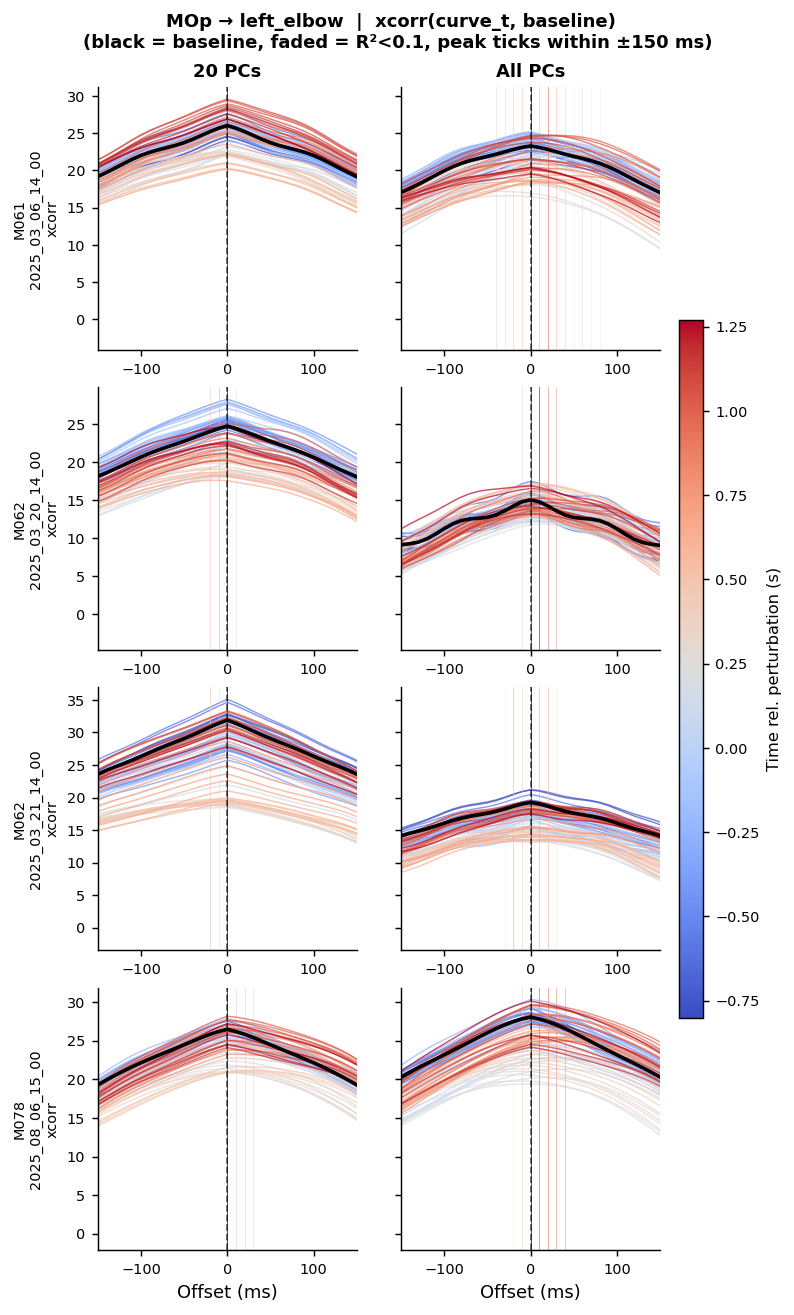

In [54]:
# ── Cross-correlation functions: 20 PCs vs all PCs, per session ───────────────
# Each line = xcorr(normalised curve at time t, normalised baseline mean).
# The peak of each line is the drift value plotted in the cell above.
# Rows = sessions, columns = conditions. Coloured by time (coolwarm).

from pathlib import Path
from scipy.signal import correlate
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

_XC_SESSIONS = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
]

_XC_DIRS = {
    '20 PCs':  Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs': Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_XC_BASELINE   = (-1.0, -0.5)   # s
_XC_R2_GATE    = 0.1
_XC_LAG_LIM_MS = 150             # ms — x-axis truncation and peak-finding window

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'figure.dpi':        130,
}

def _norm_curve(c):
    return c / (c.max() + 1e-12)

# ── load and compute xcorr functions ─────────────────────────────────────────
_xc_data = {}   # {label: {sess: {'offsets_ms', 't', 'xcorrs', 'peak_r2'}}}

for label, rdir in _XC_DIRS.items():
    _xc_data[label] = {}
    for sess in _XC_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            continue
        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else None
        if _lags is None or KEYPOINT not in _raw:
            continue

        _res      = _raw[KEYPOINT]
        _t        = np.array(sorted(_res.keys()))
        _bl_mask  = (_t >= _XC_BASELINE[0]) & (_t < _XC_BASELINE[1])
        _bl_mean  = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)
        _bl_norm  = _norm_curve(_bl_mean)

        _lag_step = _lags[1] - _lags[0]
        _n        = len(_lags)
        _offsets  = np.arange(-(_n - 1), _n) * _lag_step   # length 2n-1

        _xcorrs  = []
        _peak_r2 = []
        for ti in _t:
            _c = _norm_curve(_res[ti].mean(-1))
            _xcorrs.append(correlate(_c, _bl_norm, mode='full'))
            _peak_r2.append(_res[ti].mean(-1).max())

        _xc_data[label][sess] = {
            'offsets_ms': _offsets,
            't':          _t,
            'xcorrs':     np.array(_xcorrs),   # (n_t, 2n-1)
            'peak_r2':    np.array(_peak_r2),
        }

# ── plot ──────────────────────────────────────────────────────────────────────
_valid_sess = [s for s in _XC_SESSIONS
               if any(s in _xc_data[lbl] for lbl in _XC_DIRS)]
_labels  = list(_XC_DIRS.keys())
_n_rows  = len(_valid_sess)
_n_cols  = len(_labels)

_t_ref  = next(iter(next(iter(_xc_data.values())).values()))['t']
_t_min, _t_max = _t_ref.min(), _t_ref.max()
_cmap_t = cm.coolwarm
_norm_t = mpl.colors.Normalize(vmin=_t_min, vmax=_t_max)

with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(
        _n_rows, _n_cols,
        figsize=(_n_cols * 3, _n_rows * 2.5),
        constrained_layout=True,
        sharey='row',
    )
    if _n_rows == 1:
        axes = axes[np.newaxis, :]

    for row_i, sess in enumerate(_valid_sess):
        for col_i, label in enumerate(_labels):
            ax = axes[row_i, col_i]

            if sess not in _xc_data[label]:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
                continue

            _d        = _xc_data[label][sess]
            _offsets  = _d['offsets_ms']
            _t        = _d['t']
            _xcorrs   = _d['xcorrs']
            _peak_r2  = _d['peak_r2']

            # mask for peak-finding within ±_XC_LAG_LIM_MS
            _win_mask = np.abs(_offsets) <= _XC_LAG_LIM_MS

            ax.axvline(0, color='gray', lw=0.6, ls=':')

            for ti, (t_val, xc, pr2) in enumerate(zip(_t, _xcorrs, _peak_r2)):
                alpha = 0.7 if pr2 >= _XC_R2_GATE else 0.15
                ax.plot(_offsets, xc, color=_cmap_t(_norm_t(t_val)),
                        lw=0.8, alpha=alpha)
                if pr2 >= _XC_R2_GATE:
                    # find peak within truncation window
                    pk_idx = np.argmax(xc[_win_mask])
                    pk_offset = _offsets[_win_mask][pk_idx]
                    ax.axvline(pk_offset, color=_cmap_t(_norm_t(t_val)),
                               lw=0.4, alpha=0.3)

            # baseline mean xcorr
            _bl_mask = (_t >= _XC_BASELINE[0]) & (_t < _XC_BASELINE[1])
            _bl_xc   = _xcorrs[_bl_mask].mean(0)
            ax.plot(_offsets, _bl_xc, color='k', lw=2, zorder=5)
            bl_pk = _offsets[_win_mask][np.argmax(_bl_xc[_win_mask])]
            ax.axvline(bl_pk, color='k', lw=1, ls='--', alpha=0.6)

            n_valid = int((_peak_r2 >= _XC_R2_GATE).sum())
            print(f'  {label} | {sess}: {n_valid}/{len(_t)} bins above R²>{_XC_R2_GATE}  '
                  f'baseline xcorr peak = {bl_pk:.0f} ms')

            if row_i == 0:
                ax.set_title(label, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(f'{sess[:4]}\n{sess[5:]}\nxcorr', fontsize=8)
            if row_i == _n_rows - 1:
                ax.set_xlabel('Offset (ms)')

            ax.set_xlim(-_XC_LAG_LIM_MS, _XC_LAG_LIM_MS)

    sm = cm.ScalarMappable(cmap=_cmap_t, norm=_norm_t)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                        shrink=0.6, pad=0.01, aspect=30)
    cbar.set_label('Time rel. perturbation (s)', fontsize=9)

    fig.suptitle(
        f'{AREA} → {KEYPOINT}  |  xcorr(curve_t, baseline)  '
        f'\n(black = baseline, faded = R²<{_XC_R2_GATE}, '
        f'peak ticks within ±{_XC_LAG_LIM_MS} ms)',
        fontweight='bold', fontsize=10,
    )
    plt.show()


  [20 PCs] M061_2025_03_04_10_00: baseline peak lag = -65.6 ms  | valid bins = 70/70
  [20 PCs] M061_2025_03_06_14_00: baseline peak lag = -48.2 ms  | valid bins = 70/70
  [20 PCs] M062_2025_03_20_14_00: baseline peak lag = -48.5 ms  | valid bins = 70/70
  [20 PCs] M062_2025_03_21_14_00: baseline peak lag = 15.6 ms  | valid bins = 70/70
  [20 PCs] M078_2025_08_06_15_00: baseline peak lag = -101.9 ms  | valid bins = 70/70
  [All PCs] M061_2025_03_04_10_00: baseline peak lag = -51.5 ms  | valid bins = 70/70
  [All PCs] M061_2025_03_06_14_00: baseline peak lag = -49.6 ms  | valid bins = 70/70
  [All PCs] M062_2025_03_20_14_00: baseline peak lag = -28.6 ms  | valid bins = 70/70
  [All PCs] M062_2025_03_21_14_00: baseline peak lag = -59.3 ms  | valid bins = 70/70
  [All PCs] M078_2025_08_06_15_00: baseline peak lag = -43.3 ms  | valid bins = 70/70
  [20 PCs] M061: post-perturb peak shift = 77.7 ms  at t=0.91 s
  [20 PCs] M062: post-perturb peak shift = 3.5 ms  at t=0.25 s
  [20 PCs] M078: p

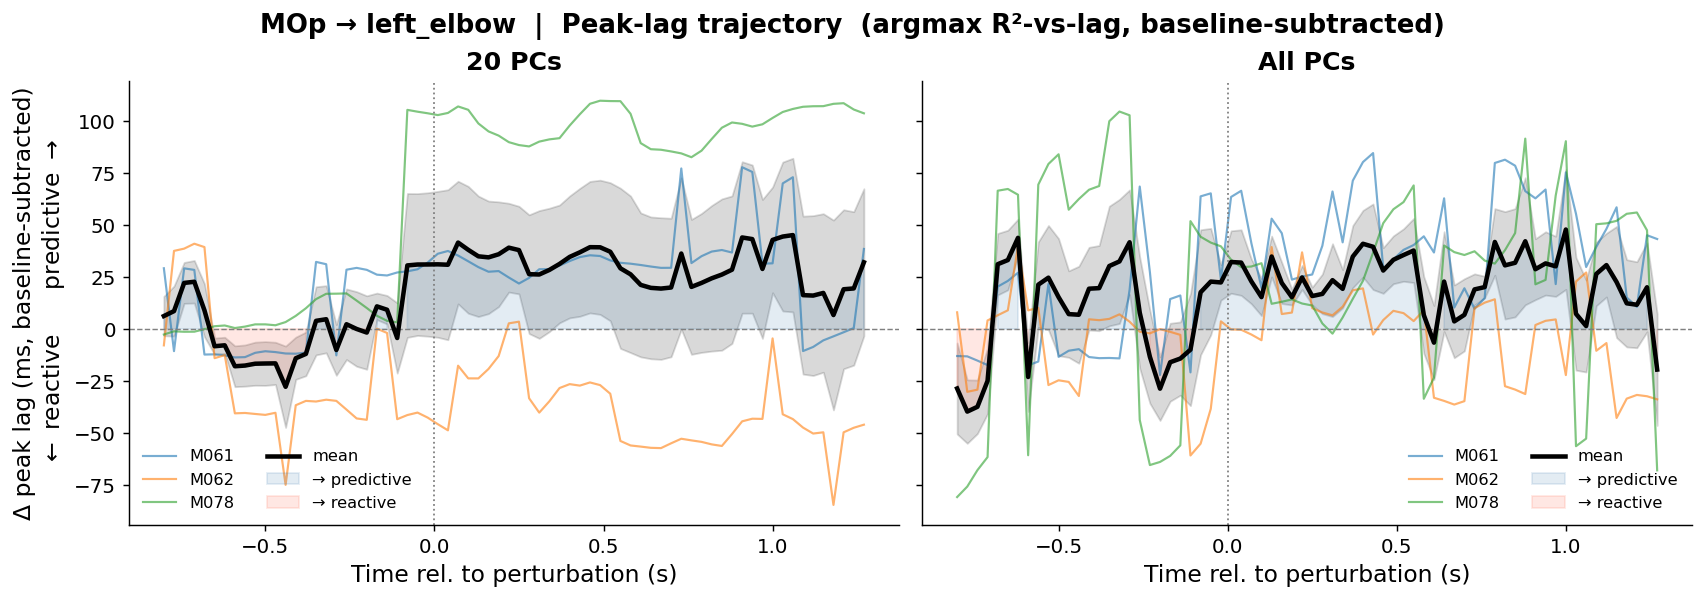

In [55]:
# ── Peak-lag trajectory: argmax of R²-vs-lag over time (20 PCs vs All PCs) ───
# At each time bin t, find the lag τ* that maximises R²(t, τ).
# Track τ*(t) over time relative to perturbation.
# Baseline-subtracted: shows change in peak lag from pre-perturbation mean.
# Positive = shifted toward future lags (predictive), negative = toward past (reactive).

from pathlib import Path
import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

_CMP_SESSIONS = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
]

_DIRS = {
    '20 PCs':  Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs': Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_BASELINE_S  = (-1.0, -0.5)
_R2_GATE     = 0.1
_MIN_ANIMALS = 2

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

def _peak_lag_ms(r2_curve, lags, gate=_R2_GATE):
    """Lag (ms) at which R² is maximised, with sub-sample parabolic refinement.
    Returns NaN if peak R² < gate."""
    if r2_curve.max() < gate:
        return np.nan
    pk = int(r2_curve.argmax())
    if 0 < pk < len(r2_curve) - 1:
        y0, y1, y2 = r2_curve[pk - 1], r2_curve[pk], r2_curve[pk + 1]
        denom = y0 - 2 * y1 + y2
        if abs(denom) > 1e-12:
            delta = 0.5 * (y0 - y2) / denom
            return float(lags[pk]) + delta * float(lags[1] - lags[0])
    return float(lags[pk])

def _safe_mean_sem(stack, min_n=_MIN_ANIMALS):
    n_valid = (~np.isnan(stack)).sum(axis=0)
    mean = np.full(stack.shape[1], np.nan)
    sem  = np.full(stack.shape[1], np.nan)
    mask = n_valid >= min_n
    if mask.any():
        mean[mask] = np.nanmean(stack[:, mask], axis=0)
        sem[mask]  = np.nanstd( stack[:, mask], axis=0) / np.sqrt(n_valid[mask])
    return mean, sem

_cmp_animals = sorted(set(s[:4] for s in _CMP_SESSIONS))
_cmap_a      = mpl.colormaps['tab10']
_cmp_colors  = {a: _cmap_a(i) for i, a in enumerate(_cmp_animals)}

_peak_results = {}   # {label: {'animal': {animal: timeseries}, 't': array}}

for label, rdir in _DIRS.items():
    _sess_peaks = {}
    for sess in _CMP_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            print(f'  [{label}] missing: {pkl_path.name}')
            continue

        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        if '_meta' not in _raw:
            print(f'  [{label}] {sess}: no _meta, skipping')
            continue
        _lags = _raw.pop('_meta')['lags_s'] * 1000   # → ms

        _res  = _raw[KEYPOINT]
        _t    = np.array(sorted(_res.keys()))
        _bl_mask = (_t >= _BASELINE_S[0]) & (_t < _BASELINE_S[1])

        _pl = np.array([_peak_lag_ms(_res[ti].mean(-1), _lags) for ti in _t])

        # baseline-subtract so y=0 = resting peak lag
        _bl_mean = np.nanmean(_pl[_bl_mask])
        _pl_bs   = _pl - _bl_mean

        print(f'  [{label}] {sess}: baseline peak lag = {_bl_mean:.1f} ms  '
              f'| valid bins = {(~np.isnan(_pl)).sum()}/{len(_t)}')

        _sess_peaks[sess] = {'t': _t, 'peak_lag_bs': _pl_bs, 'animal': sess[:4]}

    if not _sess_peaks:
        continue

    _common_t = next(iter(_sess_peaks.values()))['t']

    # average within animal before averaging across animals
    _animal_peaks = {}
    for animal in _cmp_animals:
        _s = [v['peak_lag_bs'] for v in _sess_peaks.values() if v['animal'] == animal]
        if _s:
            _animal_peaks[animal] = np.nanmean(_s, axis=0)

    _peak_results[label] = {'animal': _animal_peaks, 't': _common_t}

# ── plot ───────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True,
                             constrained_layout=True)

    for ax, (label, res) in zip(axes, _peak_results.items()):
        _t     = res['t']
        _stack = []

        for animal, _pl in res['animal'].items():
            ax.plot(_t, _pl, color=_cmp_colors[animal], lw=1.2,
                    alpha=0.6, label=animal)
            _stack.append(_pl)
            print(f'  [{label}] {animal}: post-perturb peak shift = '
                  f'{np.nanmax(_pl[_t > 0]):.1f} ms  '
                  f'at t={_t[_t > 0][np.nanargmax(_pl[_t > 0])]:.2f} s')

        if len(_stack) >= _MIN_ANIMALS:
            _gm, _gs = _safe_mean_sem(np.array(_stack))
            ax.plot(_t, _gm, color='k', lw=2.5, zorder=5, label='mean')
            ax.fill_between(_t, _gm - _gs, _gm + _gs, color='k', alpha=0.15)
            ax.fill_between(_t, _gm, 0,
                            where=(np.nan_to_num(_gm) > 0),
                            color='steelblue', alpha=0.15, label='→ predictive')
            ax.fill_between(_t, _gm, 0,
                            where=(np.nan_to_num(_gm) < 0),
                            color='tomato', alpha=0.15, label='→ reactive')

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=1.0, ls=':')
        ax.set_xlabel('Time rel. to perturbation (s)')
        ax.set_title(label, fontweight='bold')
        ax.legend(frameon=False, fontsize=9, ncol=2)

    axes[0].set_ylabel('Δ peak lag (ms, baseline-subtracted)\n'
                       r'$\leftarrow$ reactive      predictive $\rightarrow$')
    fig.suptitle(f'{AREA} → {KEYPOINT}  |  Peak-lag trajectory  '
                 f'(argmax R²-vs-lag, baseline-subtracted)',
                 fontweight='bold')
    plt.show()


  [20 PCs] M061_2025_03_04_10_00: baseline CoM = -16.6 ms  | valid bins = 70/70
  [20 PCs] M061_2025_03_06_14_00: baseline CoM = -5.7 ms  | valid bins = 70/70
  [20 PCs] M062_2025_03_20_14_00: baseline CoM = -11.5 ms  | valid bins = 70/70
  [20 PCs] M062_2025_03_21_14_00: baseline CoM = -1.8 ms  | valid bins = 70/70
  [20 PCs] M078_2025_08_06_15_00: baseline CoM = -11.0 ms  | valid bins = 70/70
  [All PCs] M061_2025_03_04_10_00: baseline CoM = -52.5 ms  | valid bins = 70/70
  [All PCs] M061_2025_03_06_14_00: baseline CoM = -11.5 ms  | valid bins = 70/70
  [All PCs] M062_2025_03_20_14_00: baseline CoM = -29.4 ms  | valid bins = 70/70
  [All PCs] M062_2025_03_21_14_00: baseline CoM = -12.0 ms  | valid bins = 70/70
  [All PCs] M078_2025_08_06_15_00: baseline CoM = -14.2 ms  | valid bins = 70/70
[20 PCs] grand mean peak CoM shift = 11.4 ms  at t=0.28 s
[All PCs] grand mean peak CoM shift = 19.5 ms  at t=0.79 s


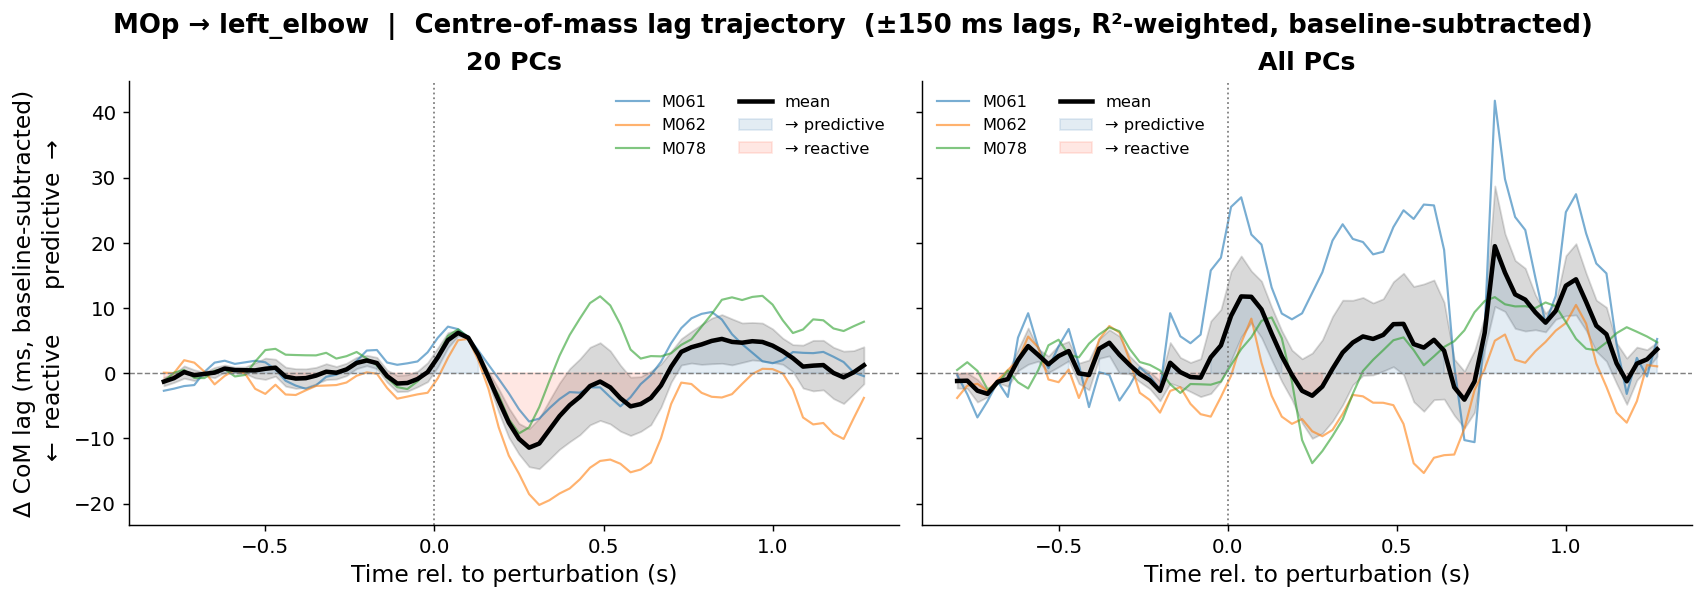

In [95]:
# ── Centre-of-mass lag trajectory: 20 PCs vs All PCs ─────────────────────────
# At each time bin t, compute the R²-weighted average lag (centre of mass).
# More robust than argmax (uses full curve) and more direct than xcorr
# (no baseline shape-matching required).
# Baseline-subtracted: y=0 = resting CoM lag.
#
# Key parameter: _COM_LAG_LIM_MS controls the lag range used for the CoM.
# Restricting the range reduces sensitivity to noisy tails at lag extremes.
# Try e.g. 100, 150, 250 (= full range) to check sensitivity.

from pathlib import Path
import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

_CMP_SESSIONS = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
]

_DIRS = {
    '20 PCs':  Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs': Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_BASELINE_S    = (-1.0, -0.5)
_R2_GATE       = 0.1     # bins where peak R² < this are excluded (→ NaN)
_COM_LAG_LIM_MS = 150    # ← lag range used for CoM: only lags in [-lim, +lim] ms
                         #   set to np.inf to use the full ±250 ms range
_MIN_ANIMALS   = 2

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

def _com_lag(r2_curve, lags, lim_ms=_COM_LAG_LIM_MS, gate=_R2_GATE):
    """R²-weighted centre-of-mass lag (ms) within ±lim_ms.
    Negative R² clipped to zero so tails don't pull the CoM.
    Returns NaN if peak R² < gate or all weights ≤ 0."""
    mask = np.abs(lags) <= lim_ms
    r2   = r2_curve[mask]
    lg   = lags[mask]
    if r2.max() < gate:
        return np.nan
    w = np.clip(r2, 0, None)
    if w.sum() < 1e-12:
        return np.nan
    return float(np.sum(lg * w) / w.sum())

def _safe_mean_sem(stack, min_n=_MIN_ANIMALS):
    n_valid = (~np.isnan(stack)).sum(axis=0)
    mean = np.full(stack.shape[1], np.nan)
    sem  = np.full(stack.shape[1], np.nan)
    mask = n_valid >= min_n
    if mask.any():
        mean[mask] = np.nanmean(stack[:, mask], axis=0)
        sem[mask]  = np.nanstd( stack[:, mask], axis=0) / np.sqrt(n_valid[mask])
    return mean, sem

_cmp_animals = sorted(set(s[:4] for s in _CMP_SESSIONS))
_cmap_a      = mpl.colormaps['tab10']
_cmp_colors  = {a: _cmap_a(i) for i, a in enumerate(_cmp_animals)}

_com_results = {}

for label, rdir in _DIRS.items():
    _sess_com = {}
    for sess in _CMP_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            print(f'  [{label}] missing: {pkl_path.name}')
            continue

        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        if '_meta' not in _raw:
            print(f'  [{label}] {sess}: no _meta, skipping')
            continue
        _lags = _raw.pop('_meta')['lags_s'] * 1000   # → ms

        _res     = _raw[KEYPOINT]
        _t       = np.array(sorted(_res.keys()))
        _bl_mask = (_t >= _BASELINE_S[0]) & (_t < _BASELINE_S[1])

        _com = np.array([_com_lag(_res[ti].mean(-1), _lags) for ti in _t])

        _bl_mean = np.nanmean(_com[_bl_mask])
        _com_bs  = _com - _bl_mean

        print(f'  [{label}] {sess}: baseline CoM = {_bl_mean:.1f} ms  '
              f'| valid bins = {(~np.isnan(_com)).sum()}/{len(_t)}')

        _sess_com[sess] = {'t': _t, 'com_bs': _com_bs, 'animal': sess[:4]}

    if not _sess_com:
        continue

    _common_t = next(iter(_sess_com.values()))['t']

    _animal_com = {}
    for animal in _cmp_animals:
        _s = [v['com_bs'] for v in _sess_com.values() if v['animal'] == animal]
        if _s:
            _animal_com[animal] = np.nanmean(_s, axis=0)

    _com_results[label] = {'animal': _animal_com, 't': _common_t}

# ── plot ───────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True,
                             constrained_layout=True)

    for ax, (label, res) in zip(axes, _com_results.items()):
        _t     = res['t']
        _stack = []

        for animal, _com in res['animal'].items():
            ax.plot(_t, _com, color=_cmp_colors[animal], lw=1.2,
                    alpha=0.6, label=animal)
            _stack.append(_com)

        if len(_stack) >= _MIN_ANIMALS:
            _gm, _gs = _safe_mean_sem(np.array(_stack))
            ax.plot(_t, _gm, color='k', lw=2.5, zorder=5, label='mean')
            ax.fill_between(_t, _gm - _gs, _gm + _gs, color='k', alpha=0.15)
            ax.fill_between(_t, _gm, 0,
                            where=(np.nan_to_num(_gm) > 0),
                            color='steelblue', alpha=0.15, label='→ predictive')
            ax.fill_between(_t, _gm, 0,
                            where=(np.nan_to_num(_gm) < 0),
                            color='tomato', alpha=0.15, label='→ reactive')
            print(f'[{label}] grand mean peak CoM shift = '
                  f'{np.nanmax(np.abs(_gm[_t > 0])):.1f} ms  '
                  f'at t={_t[_t > 0][np.nanargmax(np.abs(_gm[_t > 0]))]:.2f} s')

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=1.0, ls=':')
        ax.set_xlabel('Time rel. to perturbation (s)')
        ax.set_title(label, fontweight='bold')
        ax.legend(frameon=False, fontsize=9, ncol=2)

    axes[0].set_ylabel('Δ CoM lag (ms, baseline-subtracted)\n'
                       r'$\leftarrow$ reactive      predictive $\rightarrow$')
    fig.suptitle(f'{AREA} → {KEYPOINT}  |  Centre-of-mass lag trajectory  '
                 f'(±{_COM_LAG_LIM_MS} ms lags, R²-weighted, baseline-subtracted)',
                 fontweight='bold')
    plt.show()


  [20 PCs] M061_2025_03_06_14_00: peak past_dev = 1.765  peak future_dev = 1.201  peak |diff| = 1.290
  [20 PCs] M062_2025_03_20_14_00: peak past_dev = 4.542  peak future_dev = 2.522  peak |diff| = 2.084
  [20 PCs] M062_2025_03_21_14_00: peak past_dev = 2.426  peak future_dev = 0.879  peak |diff| = 1.821
  [20 PCs] M078_2025_08_06_15_00: peak past_dev = 1.345  peak future_dev = 1.387  peak |diff| = 1.043
  [All PCs] M061_2025_03_06_14_00: peak past_dev = 1.351  peak future_dev = 1.255  peak |diff| = 1.417
  [All PCs] M062_2025_03_20_14_00: peak past_dev = 5.163  peak future_dev = 3.176  peak |diff| = 2.008
  [All PCs] M062_2025_03_21_14_00: peak past_dev = 3.787  peak future_dev = 2.148  peak |diff| = 2.307
  [All PCs] M078_2025_08_06_15_00: peak past_dev = 1.443  peak future_dev = 1.397  peak |diff| = 1.565


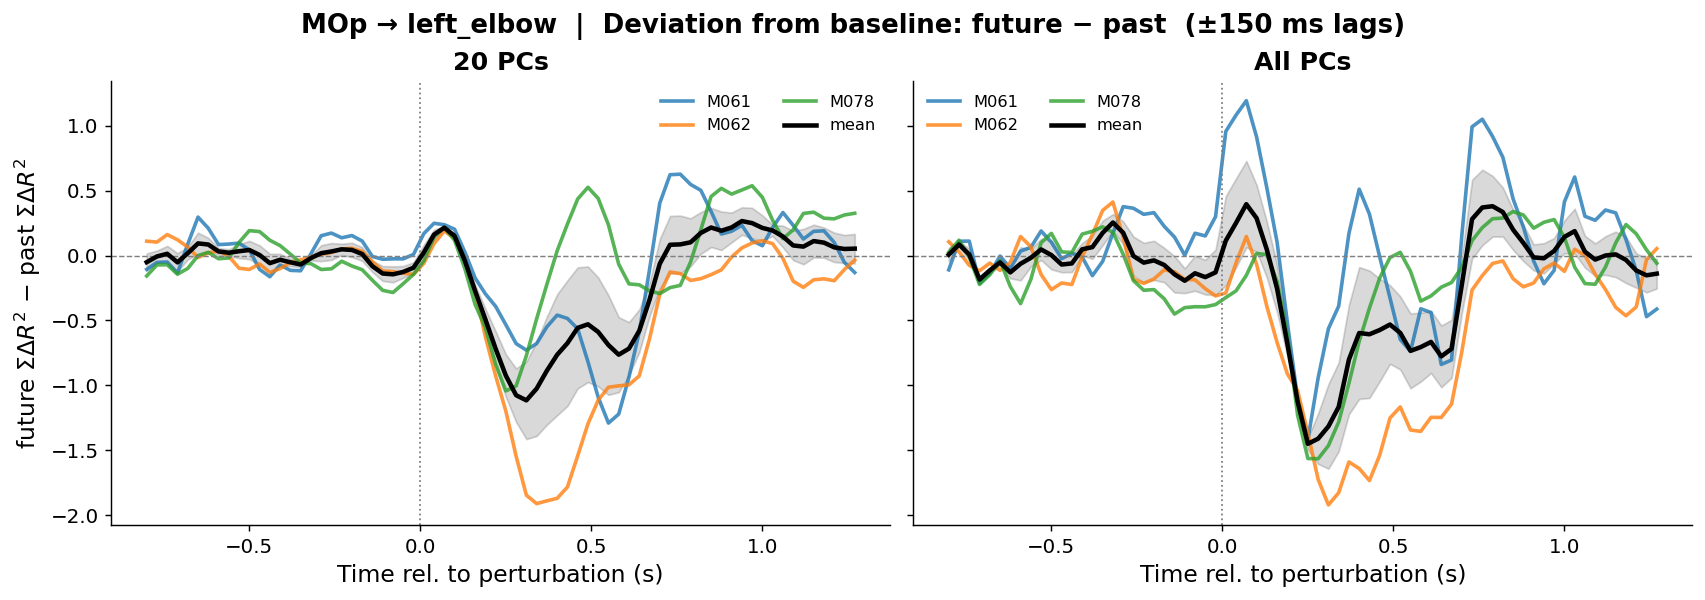

In [97]:
# ── Deviation from baseline: future vs past ΣΔR² (20 PCs vs All PCs) ─────────
# At each time bin t, compute the signed deviation from the baseline R²-vs-lag
# curve, then sum separately over past (negative) and future (positive) lags:
#   past_dev(t)   = Σ  ΔR²(t, lag)  for lag in [-lim, 0)
#   future_dev(t) = Σ  ΔR²(t, lag)  for lag in (0, +lim]
#   dev_diff(t)   = future_dev - past_dev
# Positive dev_diff → future side more elevated (predictive shift)
# Negative dev_diff → past side more elevated (reactive shift)
#
# Key parameter: _DEV_LAG_LIM_MS — symmetric lag truncation (ms).
# Try 100, 150, 200, 250 to check sensitivity.

from pathlib import Path
import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt

_CMP_SESSIONS = [
    # 'M061_2025_03_04_10_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
]

_DIRS = {
    '20 PCs':  Path('/data/equake_results/lagged_kin_dec_20_pcs/'),
    'All PCs': Path('/data/equake_results/lagged_kin_dec_all_pcs/'),
}

_BASELINE_S      = (-0.8, -0.3)
_DEV_LAG_LIM_MS  = 150    # ← symmetric lag truncation in ms
                           #   only lags in [-lim, 0) and (0, +lim] are summed
_MIN_ANIMALS     = 2

_PRES_RC = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        130,
}

def _safe_mean_sem(stack, min_n=_MIN_ANIMALS):
    n_valid = (~np.isnan(stack)).sum(axis=0)
    mean = np.full(stack.shape[1], np.nan)
    sem  = np.full(stack.shape[1], np.nan)
    mask = n_valid >= min_n
    if mask.any():
        mean[mask] = np.nanmean(stack[:, mask], axis=0)
        sem[mask]  = np.nanstd( stack[:, mask], axis=0) / np.sqrt(n_valid[mask])
    return mean, sem

_cmp_animals = sorted(set(s[:4] for s in _CMP_SESSIONS))
_cmap_a      = mpl.colormaps['tab10']
_cmp_colors  = {a: _cmap_a(i) for i, a in enumerate(_cmp_animals)}

_dev_results = {}   # {label: {'animal': {animal: diff_timeseries}, 't': array}}

for label, rdir in _DIRS.items():
    _sess_diff = {}
    for sess in _CMP_SESSIONS:
        pkl_path = rdir / f'lagged_dec_{AREA}_{sess}.pkl'
        if not pkl_path.exists():
            print(f'  [{label}] missing: {pkl_path.name}')
            continue

        with open(pkl_path, 'rb') as f:
            _raw = pickle.load(f)

        if '_meta' not in _raw:
            print(f'  [{label}] {sess}: no _meta, skipping')
            continue
        _lags = _raw.pop('_meta')['lags_s'] * 1000   # → ms

        _res     = _raw[KEYPOINT]
        _t       = np.array(sorted(_res.keys()))
        _bl_mask = (_t >= _BASELINE_S[0]) & (_t < _BASELINE_S[1])

        _past_mask   = (_lags >= -_DEV_LAG_LIM_MS) & (_lags < 0)
        _future_mask = (_lags > 0) & (_lags <= _DEV_LAG_LIM_MS)

        # baseline mean R²-vs-lag curve
        _bl_curve = np.array([_res[ti].mean(-1) for ti in _t[_bl_mask]]).mean(0)

        # signed deviation from baseline at each time bin, summed over each side
        _past_dev   = np.array([
            np.sum(_res[ti].mean(-1)[_past_mask]   - _bl_curve[_past_mask])
            for ti in _t
        ])
        _future_dev = np.array([
            np.sum(_res[ti].mean(-1)[_future_mask] - _bl_curve[_future_mask])
            for ti in _t
        ])
        _diff = _future_dev - _past_dev

        print(f'  [{label}] {sess}: '
              f'peak past_dev = {_past_dev.max():.3f}  '
              f'peak future_dev = {_future_dev.max():.3f}  '
              f'peak |diff| = {np.abs(_diff).max():.3f}')

        _sess_diff[sess] = {
            't': _t, 'past': _past_dev, 'future': _future_dev,
            'diff': _diff, 'animal': sess[:4]
        }

    if not _sess_diff:
        continue

    _common_t = next(iter(_sess_diff.values()))['t']

    # average within animal
    _animal_diff = {}
    for animal in _cmp_animals:
        _s = [v['diff'] for v in _sess_diff.values() if v['animal'] == animal]
        if _s:
            _animal_diff[animal] = np.nanmean(_s, axis=0)

    _dev_results[label] = {'animal': _animal_diff, 't': _common_t}

# ── plot ───────────────────────────────────────────────────────────────────────
with mpl.rc_context(_PRES_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True,
                             constrained_layout=True)

    for ax, (label, res) in zip(axes, _dev_results.items()):
        _t     = res['t']
        _stack = []

        for animal, _diff in res['animal'].items():
            ax.plot(_t, _diff, color=_cmp_colors[animal], lw=2,
                    alpha=0.8, label=animal)
            _stack.append(_diff)

        if len(_stack) >= _MIN_ANIMALS:
            _gm, _gs = _safe_mean_sem(np.array(_stack))
            ax.plot(_t, _gm, color='k', lw=2.5, zorder=5, label='mean')
            ax.fill_between(_t, _gm - _gs, _gm + _gs, color='k', alpha=0.15)
            # ax.fill_between(_t, _gm, 0,
            #                 where=(np.nan_to_num(_gm) > 0),
            #                 color='steelblue', alpha=0.15, label='future > past')
            # ax.fill_between(_t, _gm, 0,
            #                 where=(np.nan_to_num(_gm) < 0),
            #                 color='tomato', alpha=0.5, label='past > future')

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=1.0, ls=':')
        ax.set_xlabel('Time rel. to perturbation (s)')
        ax.set_title(label, fontweight='bold')
        ax.legend(frameon=False, fontsize=9, ncol=2)

    axes[0].set_ylabel(r'future $\Sigma\Delta R^2$ $-$ past $\Sigma\Delta R^2$')
    fig.suptitle(f'{AREA} → {KEYPOINT}  |  Deviation from baseline: future − past  '
                 f'(±{_DEV_LAG_LIM_MS} ms lags)',
                 fontweight='bold')
    plt.show()


In [65]:
_past_dev

array([-0.60558558, -0.71701673, -0.53889275, -0.03787642,  0.01940363,
       -0.44023506, -0.51599679, -0.3422591 , -0.21984091,  0.02352718,
       -0.00682165, -0.03470934,  0.01019248,  0.0430262 ,  0.28389537,
        0.31083686,  0.19969904,  0.15126249,  0.2411205 ,  0.2768991 ,
        0.07202944, -0.03995168, -0.27412857, -0.5019272 , -0.7383999 ,
       -0.98458433, -1.21108138, -1.65754381, -1.92501619, -2.31681465,
       -2.66525434, -2.2903018 , -1.8603578 , -1.81412647, -1.15108728,
       -0.46069786,  0.12020924,  0.71768607,  1.19198884,  0.97643496,
        0.44191915,  0.41132459,  0.61905811,  0.20815608, -0.23565568,
       -0.40557844, -0.65738868, -0.38816612,  0.09590444,  0.24895998,
       -0.22074454, -0.79044387, -0.89661368, -0.95641287, -1.02251479,
       -1.13562933, -1.48804919, -1.60153388, -1.47517148, -1.44900876,
       -1.78254181, -1.71678704, -1.69394241, -1.34816001, -1.00544794,
       -0.97145675, -0.9902957 , -1.11111782, -1.10324622, -1.01

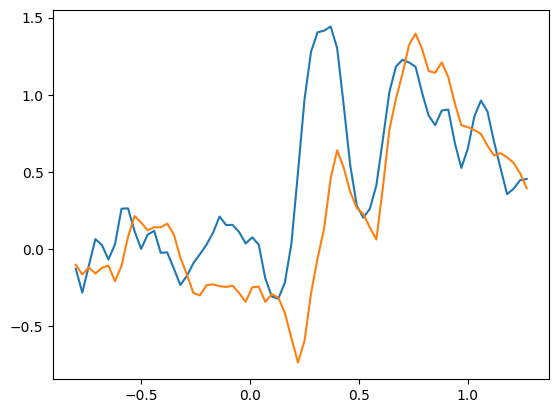

In [94]:
plt.plot(_t, _past_dev)
plt.plot(_t, _future_dev)

plt.show()

# Control

M061_2025_03_06_14_00: 70 time pts | 5 shuffles
M062_2025_03_20_14_00: 70 time pts | 5 shuffles


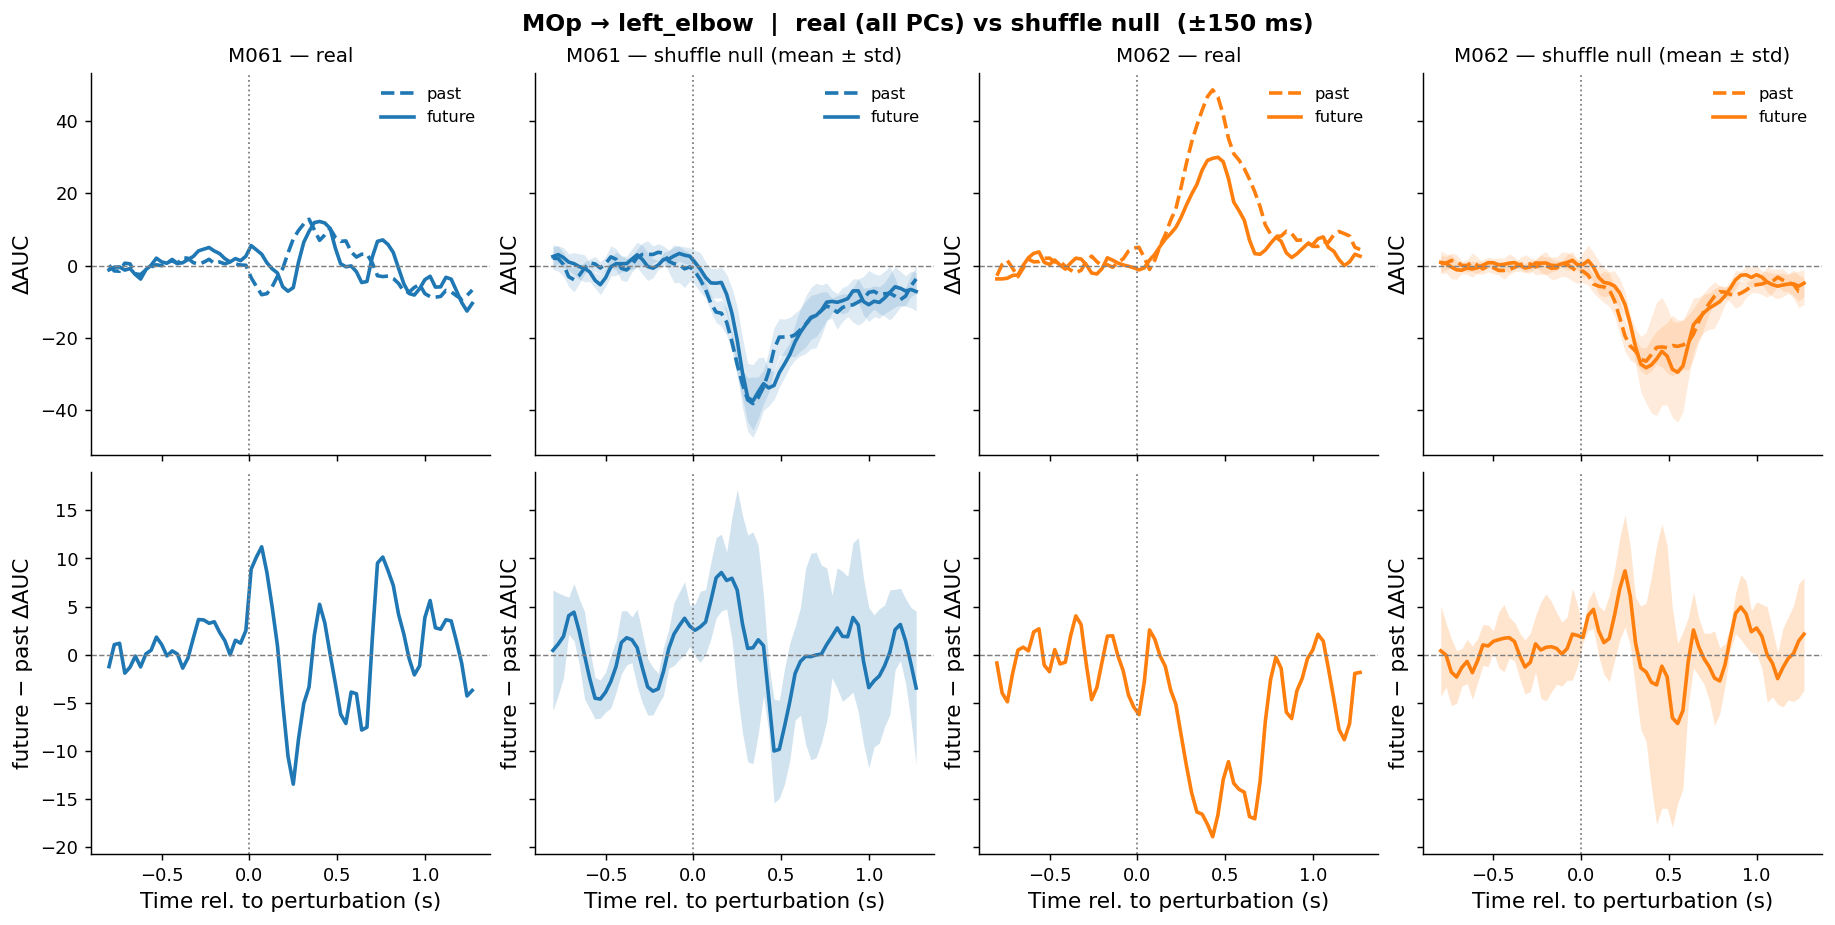

M061_2025_03_06_14_00:  real peak diff = -13.46  |  null at peak: 6.72 ± 10.47
M062_2025_03_20_14_00:  real peak diff = -18.93  |  null at peak: -3.15 ± 14.48


In [26]:
# ── AUC past vs future: real (all PCs) vs shuffle null ────────────────────────
# Self-contained. Plots real vs shuffle null side-by-side for each session.
# Null shown as mean ± 1 std across shuffle iterations.

import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path

_SESSIONS    = ['M061_2025_03_06_14_00', 'M062_2025_03_20_14_00']
_AREA        = 'MOp'
_KEYPOINT    = 'left_elbow'
_REAL_DIR    = Path('/data/equake_results/lagged_kin_dec_all_pcs/')
_SHUFF_DIR   = Path('/data/equake_results/lagged_kin_dec_shuffle/')
_BASELINE_S  = (-1.0, -0.3)
_LAG_LIM_MS  = 150

_RC = {
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'figure.dpi': 130,
}
_cmap = mpl.colormaps['tab10']

def _compute_auc(res, lags, t, bl_mask, past_mask, future_mask):
    past   = np.array([np.trapz(res[ti].mean(-1)[past_mask],   lags[past_mask])   for ti in t])
    future = np.array([np.trapz(res[ti].mean(-1)[future_mask], lags[future_mask]) for ti in t])
    past   -= past[bl_mask].mean()
    future -= future[bl_mask].mean()
    return past, future, future - past

def _compute_shuffle_auc(shuffles, lags, t, bl_mask, past_mask, future_mask):
    n = len(shuffles)
    p = np.zeros((n, len(t)))
    q = np.zeros((n, len(t)))
    for si, sh in enumerate(shuffles):
        for ti, ts in enumerate(t):
            r2 = sh[ts].mean(-1)
            p[si, ti] = np.trapz(r2[past_mask],   lags[past_mask])
            q[si, ti] = np.trapz(r2[future_mask], lags[future_mask])
    p -= p[:, bl_mask].mean(1, keepdims=True)
    q -= q[:, bl_mask].mean(1, keepdims=True)
    d  = q - p
    return p, q, d

# ── load all sessions ──────────────────────────────────────────────────────────
data = {}
for sess in _SESSIONS:
    # real
    with open(_REAL_DIR / f'lagged_dec_{_AREA}_{sess}.pkl', 'rb') as f:
        _real = pickle.load(f)
    _lags_r = _real.pop('_meta')['lags_s'] * 1000
    _res    = _real[_KEYPOINT]
    _t_r    = np.array(sorted(_res.keys()))
    _bl_r   = (_t_r >= _BASELINE_S[0]) & (_t_r < _BASELINE_S[1])
    _pm_r   = (_lags_r >= -_LAG_LIM_MS) & (_lags_r < 0)
    _fm_r   = (_lags_r > 0) & (_lags_r <= _LAG_LIM_MS)
    past_r, future_r, diff_r = _compute_auc(_res, _lags_r, _t_r, _bl_r, _pm_r, _fm_r)

    # shuffle
    with open(_SHUFF_DIR / f'lagged_dec_shuffle_{_AREA}_{sess}.pkl', 'rb') as f:
        _shuf = pickle.load(f)
    _lags_s   = _shuf['_meta']['lags_s'] * 1000
    _shuffles = _shuf['shuffles']
    _t_s      = np.array(sorted(_shuffles[0].keys()))
    _bl_s     = (_t_s >= _BASELINE_S[0]) & (_t_s < _BASELINE_S[1])
    _pm_s     = (_lags_s >= -_LAG_LIM_MS) & (_lags_s < 0)
    _fm_s     = (_lags_s > 0) & (_lags_s <= _LAG_LIM_MS)
    p_sh, q_sh, d_sh = _compute_shuffle_auc(_shuffles, _lags_s, _t_s, _bl_s, _pm_s, _fm_s)

    data[sess] = dict(
        t_r=_t_r, past_r=past_r, future_r=future_r, diff_r=diff_r,
        t_s=_t_s,
        past_mean=p_sh.mean(0),   past_std=p_sh.std(0),
        future_mean=q_sh.mean(0), future_std=q_sh.std(0),
        diff_mean=d_sh.mean(0),   diff_std=d_sh.std(0),
        n_sh=len(_shuffles),
    )
    print(f'{sess}: {len(_t_r)} time pts | {data[sess]["n_sh"]} shuffles')

# ── plot: 2 rows × 4 cols (real | null for each session) ──────────────────────
n_sess = len(_SESSIONS)
with mpl.rc_context(_RC):
    fig, axes = plt.subplots(2, n_sess * 2, figsize=(7 * n_sess, 7),
                             sharex=True, constrained_layout=True, sharey='row')
    fig.suptitle(f'{_AREA} → {_KEYPOINT}  |  real (all PCs) vs shuffle null  (±{_LAG_LIM_MS} ms)',
                 fontweight='bold', fontsize=13)

    for si, sess in enumerate(_SESSIONS):
        d  = data[sess]
        _c = _cmap(si)

        # ── top row: past vs future ──
        for col, (t_ax, past_line, future_line, past_sd, future_sd, subtitle) in enumerate([
            (d['t_r'], d['past_r'], d['future_r'], None, None,
             f'{sess[:4]} — real'),
            (d['t_s'], d['past_mean'], d['future_mean'], d['past_std'], d['future_std'],
             f'{sess[:4]} — shuffle null (mean ± std)'),
        ]):
            ax = axes[0, si * 2 + col]
            ax.plot(t_ax, past_line,   color=_c, lw=2.0, ls='--', label='past')
            ax.plot(t_ax, future_line, color=_c, lw=2.0, ls='-',  label='future')
            if past_sd is not None:
                ax.fill_between(t_ax, past_line - past_sd,     past_line + past_sd,
                                color=_c, alpha=0.15, lw=0)
                ax.fill_between(t_ax, future_line - future_sd, future_line + future_sd,
                                color=_c, alpha=0.15, lw=0)
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(0, color='gray', lw=1.0, ls=':')
            ax.set_title(subtitle)
            ax.set_ylabel('ΔAUC')
            ax.legend(frameon=False, fontsize=9)

        # ── bottom row: future − past ──
        for col, (t_ax, diff_line, diff_sd) in enumerate([
            (d['t_r'], d['diff_r'], None),
            (d['t_s'], d['diff_mean'], d['diff_std']),
        ]):
            ax = axes[1, si * 2 + col]
            ax.plot(t_ax, diff_line, color=_c, lw=2.0)
            if diff_sd is not None:
                ax.fill_between(t_ax, diff_line - diff_sd, diff_line + diff_sd,
                                color=_c, alpha=0.20, lw=0)
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(0, color='gray', lw=1.0, ls=':')
            ax.set_xlabel('Time rel. to perturbation (s)')
            ax.set_ylabel('future − past ΔAUC')

    plt.show()

for sess in _SESSIONS:
    d = data[sess]
    peak_idx = np.abs(d['diff_r']).argmax()
    print(f'{sess}:  real peak diff = {d["diff_r"][peak_idx]:.2f}'
          f'  |  null at peak: {d["diff_mean"][peak_idx]:.2f} ± {d["diff_std"][peak_idx]:.2f}')


  M061_2025_03_04_10_00: 67 valid time points
  M061_2025_03_05_14_00: 59 valid time points
  M061_2025_03_06_14_00: 67 valid time points
  M062_2025_03_20_14_00: 67 valid time points
  M062_2025_03_21_14_00: 67 valid time points
  M063_2025_03_13_14_00: 67 valid time points
  M063_2025_03_14_15_30: 67 valid time points
  M078_2025_08_06_15_00: 67 valid time points

Animals loaded: ['M061', 'M062', 'M063', 'M078']


/tmp/ipykernel_1043032/1310265399.py:83: RuntimeWarning: Mean of empty slice
  animal_velocities[animal] = np.nanmean(sess_vels, axis=0)
/tmp/ipykernel_1043032/1310265399.py:89: RuntimeWarning: Mean of empty slice
  _grand     = np.nanmean(_stack, axis=0)
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


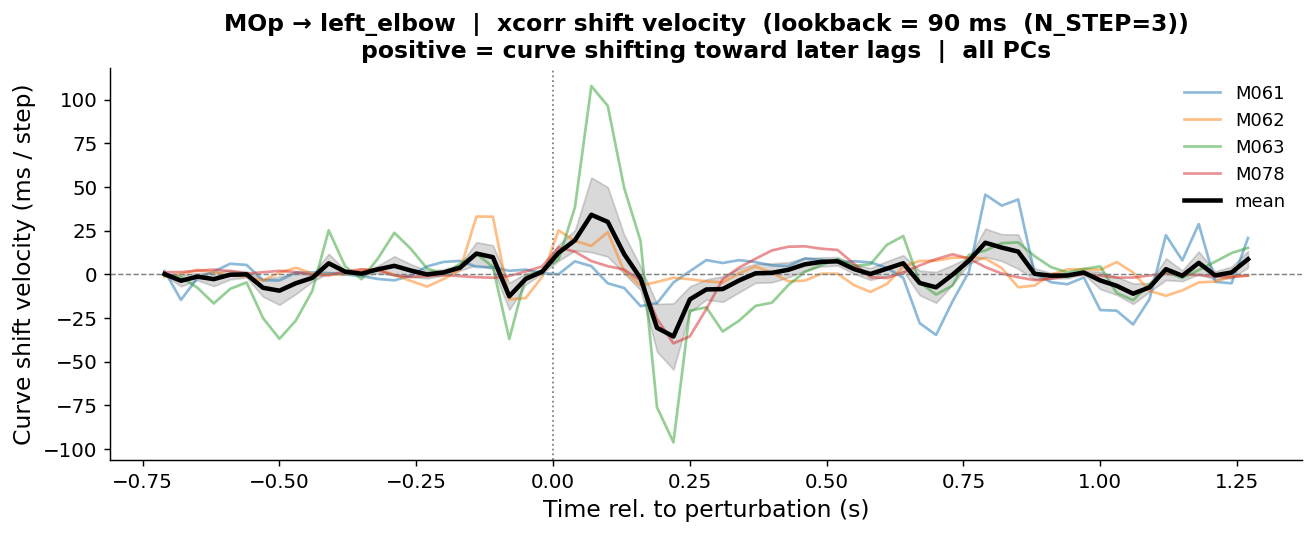

Grand mean peak velocity: -35.56 ms/step  at t = 0.22 s


In [1]:
# ── Curve-shift velocity: xcorr(curve_t, curve_{t-step}) — all PCs ────────────
# Self-contained. For each time point t, cross-correlates the R²-vs-lag curve
# with the curve N_STEP time steps earlier. The xcorr peak offset = how much
# the curve has shifted in the last N_STEP * dt seconds.
# This is the "velocity" of the encoding shift, not the total displacement.

import pickle, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate

_SESSIONS = {
    'M061': ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00'],
    'M062': ['M062_2025_03_20_14_00', 'M062_2025_03_21_14_00'],
    'M063': ['M063_2025_03_13_14_00', 'M063_2025_03_14_15_30'],
    'M078': ['M078_2025_08_06_15_00'],
}
_AREA        = 'MOp'
_KEYPOINT    = 'left_elbow'
_RESULTS_DIR = Path('/data/equake_results/lagged_kin_dec_all_pcs/')
_N_STEP      = 3      # compare curve(t) vs curve(t - N_STEP * dt); dt=0.03s → 90ms lookback
_R2_GATE     = 0.05   # skip time points where max R² < gate (curve is flat/noise)

_RC = {
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'figure.dpi': 130,
}
_cmap = mpl.colormaps['tab10']


def _xcorr_peak_ms(curve_a, curve_b, lags_ms):
    """Offset (ms) that maximises xcorr(curve_a, curve_b).
    Positive = curve_a is shifted to the right (later lags) relative to curve_b."""
    w_a = np.clip(curve_a, 0, None)
    w_b = np.clip(curve_b, 0, None)
    if w_a.max() < _R2_GATE or w_b.max() < _R2_GATE:
        return np.nan
    xc      = correlate(w_a, w_b, mode='full')
    dl      = lags_ms[1] - lags_ms[0]
    offsets = np.arange(-(len(lags_ms) - 1), len(lags_ms)) * dl
    pk      = int(xc.argmax())
    # sub-sample parabolic refinement
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        denom = y0 - 2 * y1 + y2
        if abs(denom) > 1e-12:
            return offsets[pk] + 0.5 * (y0 - y2) / denom * dl
    return float(offsets[pk])


# ── load and compute per session ───────────────────────────────────────────────
animal_velocities = {}
_common_t = None

for animal, sessions in _SESSIONS.items():
    sess_vels = []
    for sess in sessions:
        fpath = _RESULTS_DIR / f'lagged_dec_{_AREA}_{sess}.pkl'
        if not fpath.exists():
            print(f'  Missing: {fpath.name}')
            continue
        with open(fpath, 'rb') as f:
            _raw = pickle.load(f)
        _lags = _raw.pop('_meta')['lags_s'] * 1000 if '_meta' in _raw else None
        if _lags is None:
            print(f'  No _meta in {sess}, skipping')
            continue
        _res = _raw[_KEYPOINT]
        _t   = np.array(sorted(_res.keys()))
        if _common_t is None:
            _common_t = _t

        vel = np.full(len(_t), np.nan)
        for i in range(_N_STEP, len(_t)):
            curve_now  = _res[_t[i]].mean(-1)
            curve_prev = _res[_t[i - _N_STEP]].mean(-1)
            vel[i] = _xcorr_peak_ms(curve_now, curve_prev, _lags)

        sess_vels.append(vel)
        print(f'  {sess}: {np.sum(~np.isnan(vel))} valid time points')

    if sess_vels:
        animal_velocities[animal] = np.nanmean(sess_vels, axis=0)

print(f'\nAnimals loaded: {list(animal_velocities.keys())}')

# ── grand mean ─────────────────────────────────────────────────────────────────
_stack     = np.array([animal_velocities[a] for a in animal_velocities])
_grand     = np.nanmean(_stack, axis=0)
_grand_sem = np.nanstd(_stack, axis=0) / np.sqrt(np.sum(~np.isnan(_stack), axis=0))

# ── plot ───────────────────────────────────────────────────────────────────────
_dt_label = f'lookback = {int(0.03 * _N_STEP * 1000)} ms  (N_STEP={_N_STEP})'

with mpl.rc_context(_RC):
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    for i, (animal, vel) in enumerate(animal_velocities.items()):
        ax.plot(_common_t, vel, color=_cmap(i), lw=1.5, alpha=0.5, label=animal)

    ax.plot(_common_t, _grand, color='k', lw=2.5, zorder=5, label='mean')
    ax.fill_between(_common_t, _grand - _grand_sem, _grand + _grand_sem,
                    color='k', alpha=0.15)

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Curve shift velocity (ms / step)')
    ax.set_title(
        f'{_AREA} → {_KEYPOINT}  |  xcorr shift velocity  ({_dt_label})\n'
        f'positive = curve shifting toward later lags  |  all PCs',
        fontweight='bold'
    )
    ax.legend(frameon=False, fontsize=10)
    plt.show()

_peak_idx = np.nanargmax(np.abs(_grand))
print(f'Grand mean peak velocity: {_grand[_peak_idx]:.2f} ms/step  '
      f'at t = {_common_t[_peak_idx]:.2f} s')